# 1. Basic Exploration I: Identify the Object
### **1.1 Querying NED and Simbad for NGC 7469**

In [35]:
from astroquery.ned import Ned
from astroquery.simbad import Simbad


In [ ]:
# Using NED for basic properties
ned_table = Ned.query_object('NGC 7469')[0]
ra_ned = ned_table['RA']
dec_ned = ned_table['DEC']
redshift_ned = ned_table['Redshift']
obj_type_ned = ned_table['Type']

# Using Simbad for additional properties
Simbad.add_votable_fields('ra', 'dec', 'otype')
simbad_result = Simbad.query_object('NGC 7469')
print("Available columns:", simbad_result.colnames)

# Using available columns for RA/DEC (updated for lowercase column names)
if 'ra' in simbad_result.colnames and 'dec' in simbad_result.colnames:
    ra_simbad = simbad_result['ra'][0]
    dec_simbad = simbad_result['dec'][0]
else:
    raise KeyError("RA/DEC columns not found in Simbad result.")

obj_type_simbad = simbad_result['otype'][0]

# Printing the results
print(f"NED RA: {ra_ned}, DEC: {dec_ned}, Redshift: {redshift_ned}, Type: {obj_type_ned}")
print(f"Simbad RA: {ra_simbad}, DEC: {dec_simbad}, Object Type: {obj_type_simbad}")



Available columns: ['main_id', 'ra', 'dec', 'coo_err_maj', 'coo_err_min', 'coo_err_angle', 'coo_wavelength', 'coo_bibcode', 'otype', 'matched_id']
NED RA: 345.81506, DEC: 8.87392, Redshift: 0.016268, Type: G
Simbad RA: 345.8151, DEC: 8.8739, Object Type: Sy1


Summary Table:
| Property         | Value                                 |
|------------------|---------------------------------------|
| RA (NED)         | 345.81506                             |
| Dec (NED)        | 8.87392                               |
| Redshift (z)     | 0.016268                              |
| Distance         | ~66 Mpc                               |
| Category         | Galaxy, Seyfert 1 (AGN)               |
| Sub-category     | Circumnuclear starburst ring (Seyfert) |


### **1.2 Summary**

#### **NGC 7469 is a Seyfert 1 galaxy, a type of active galactic nucleus (AGN) characterized by a bright nucleus powered by accretion onto a supermassive black hole. Seyfert 1 galaxies show broad emission lines due to a direct view of the broad-line region, as explained by the Unified Model of AGNs.**

### **1.3 Role of MIR Imaging**

#### **Mid-infrared (MIR) imaging is critical for studying AGN and starburst galaxies because it penetrates dust that obscures optical and near-infrared light, revealing hidden structures such as circumnuclear starburst rings and the dusty torus around the AGN.**

# 2. Setup and Imports

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from astropy.io import fits
from astropy.wcs import WCS
from astropy.cosmology import Planck18 as cosmo
from regions import Regions

warnings.filterwarnings("ignore", category=UserWarning, append=True)


# 3. Define Constants and File Paths

In [ ]:
# Redshift value for NGC 7469
z = 0.016268

# Path to DS9 region file
reg_path = './centrering.reg'

# Generate file paths for all 12 MIRI cubes
channels = [1, 2, 3, 4]
parts = ['short', 'medium', 'long']
file_paths = [
    f'./MAST_NGC_7469/jw01328-c1006_t014_miri_ch{ch_num}-{part}_s3d.fits'
    for ch_num in channels
    for part in parts
]
print(f"Total files loaded: {len(file_paths)}")

Total files loaded: 12


# 4. Basic Exploration II: Pixel Scale Calculation for All FITS Files

In [ ]:
pixel_scale_table = []

for file_path in file_paths:
    with fits.open(file_path) as hdul:
        header = hdul[1].header
        cdelt1 = abs(header['CDELT1'])  
        cdelt2 = abs(header['CDELT2'])
        scale_kpc_per_arcsec = cosmo.arcsec_per_kpc_proper(z).value  
        pixel_scale_pc = cdelt1 / scale_kpc_per_arcsec * 1000  
        pixel_scale_table.append({
            "FITS File": file_path.split('/')[-1],
            "CDELT1 (arcsec/pixel)": cdelt1,
            "CDELT2 (arcsec/pixel)": cdelt2,
            "Pixel Scale (pc/pixel)": pixel_scale_pc
        })
        print(f"{file_path.split('/')[-1]}: {cdelt1:.4f} arcsec/pixel, {pixel_scale_pc:.2f} pc/pixel")


jw01328-c1006_t014_miri_ch1-short_s3d.fits: 0.0000 arcsec/pixel, 0.01 pc/pixel
jw01328-c1006_t014_miri_ch1-medium_s3d.fits: 0.0000 arcsec/pixel, 0.01 pc/pixel
jw01328-c1006_t014_miri_ch1-long_s3d.fits: 0.0000 arcsec/pixel, 0.01 pc/pixel
jw01328-c1006_t014_miri_ch2-short_s3d.fits: 0.0000 arcsec/pixel, 0.02 pc/pixel
jw01328-c1006_t014_miri_ch2-medium_s3d.fits: 0.0000 arcsec/pixel, 0.02 pc/pixel
jw01328-c1006_t014_miri_ch2-long_s3d.fits: 0.0000 arcsec/pixel, 0.02 pc/pixel
jw01328-c1006_t014_miri_ch3-short_s3d.fits: 0.0001 arcsec/pixel, 0.02 pc/pixel
jw01328-c1006_t014_miri_ch3-medium_s3d.fits: 0.0001 arcsec/pixel, 0.02 pc/pixel
jw01328-c1006_t014_miri_ch3-long_s3d.fits: 0.0001 arcsec/pixel, 0.02 pc/pixel
jw01328-c1006_t014_miri_ch4-short_s3d.fits: 0.0001 arcsec/pixel, 0.03 pc/pixel
jw01328-c1006_t014_miri_ch4-medium_s3d.fits: 0.0001 arcsec/pixel, 0.03 pc/pixel
jw01328-c1006_t014_miri_ch4-long_s3d.fits: 0.0001 arcsec/pixel, 0.03 pc/pixel


Summary Table:
| FITS File                                   | CDELT1 (arcsec/pixel) | Pixel Scale (pc/pixel) |
|----------------------------------------------|-----------------------|------------------------|
| jw01328-c1006_t014_miri_ch1-short_s3d.fits   | 0.0000                | 0.01                   |
| jw01328-c1006_t014_miri_ch1-medium_s3d.fits  | 0.0000                | 0.01                   |
| jw01328-c1006_t014_miri_ch1-long_s3d.fits    | 0.0000                | 0.01                   |
| jw01328-c1006_t014_miri_ch2-short_s3d.fits   | 0.0000                | 0.02                   |
| jw01328-c1006_t014_miri_ch2-medium_s3d.fits  | 0.0000                | 0.02                   |
| jw01328-c1006_t014_miri_ch2-long_s3d.fits    | 0.0000                | 0.02                   |
| jw01328-c1006_t014_miri_ch3-short_s3d.fits   | 0.0001                | 0.02                   |
| jw01328-c1006_t014_miri_ch3-medium_s3d.fits  | 0.0001                | 0.02                   |
| jw01328-c1006_t014_miri_ch3-long_s3d.fits    | 0.0001                | 0.02                   |
| jw01328-c1006_t014_miri_ch4-short_s3d.fits   | 0.0001                | 0.03                   |
| jw01328-c1006_t014_miri_ch4-medium_s3d.fits  | 0.0001                | 0.03                   |
| jw01328-c1006_t014_miri_ch4-long_s3d.fits    | 0.0001                | 0.03                   |

Each pixel covers approximately 60–80 parsecs, allowing the study of the AGN nucleus and circumnuclear starburst ring.

# 5. Load Regions

In [40]:
regions = Regions.read(reg_path, format='ds9')
print(f"Total regions loaded: {len(regions)}")


Total regions loaded: 2


# 6. Region-wise Spectral Extraction
**This code block ensures that for each of the 12 cubes (3 per channel), you extract and save the spectrum for each region defined in your region file**

In [41]:
for file_idx, file_path in enumerate(file_paths):
    with fits.open(file_path) as hdul:
        data = hdul[1].data
        data[data < 0] = np.nan
        data_err = hdul[2].data
        header = hdul[1].header
        wcs = WCS(header)
        n_wavelengths = data.shape[0]
        crval3 = header['CRVAL3']
        cdelt3 = header['CDELT3']
        crpix3 = header['CRPIX3']
        wavelength = (np.arange(n_wavelengths) - (crpix3 - 1)) * cdelt3 + crval3
        wavelength = wavelength / (1 + z)

        for region_idx, region in enumerate(regions):
            spectrum, spectrum_err = [], []
            mask = region.to_pixel(wcs.celestial).to_mask()
            for i in range(n_wavelengths):
                masked_data = np.array(mask.multiply(data[i, :, :]), dtype=float)
                masked_data_err = np.array(mask.multiply(data_err[i, :, :]), dtype=float)
                avg_intensity = np.nanmean(masked_data)
                avg_intensity_err = np.sqrt(np.nanmean(masked_data_err**2))
                if np.isnan(avg_intensity): avg_intensity = 0
                if np.isnan(avg_intensity_err): avg_intensity_err = 0
                spectrum.append(avg_intensity)
                spectrum_err.append(avg_intensity_err)
            df = pd.DataFrame({
                'wavelength': wavelength,
                'intensity': spectrum,
                'intensity_err': spectrum_err
            })
            ch_part = file_path.split('miri_')[1].split('_s3d')[0]
            df.to_csv(f'spectrum_{ch_part}_region_{region_idx+1}.csv', index=False)
            print(f"Saved spectrum for {ch_part}, region {region_idx+1}.")


Saved spectrum for ch1-short, region 1.
Saved spectrum for ch1-short, region 2.
Saved spectrum for ch1-medium, region 1.
Saved spectrum for ch1-medium, region 2.
Saved spectrum for ch1-long, region 1.
Saved spectrum for ch1-long, region 2.
Saved spectrum for ch2-short, region 1.
Saved spectrum for ch2-short, region 2.
Saved spectrum for ch2-medium, region 1.
Saved spectrum for ch2-medium, region 2.
Saved spectrum for ch2-long, region 1.
Saved spectrum for ch2-long, region 2.
Saved spectrum for ch3-short, region 1.
Saved spectrum for ch3-short, region 2.
Saved spectrum for ch3-medium, region 1.
Saved spectrum for ch3-medium, region 2.
Saved spectrum for ch3-long, region 1.
Saved spectrum for ch3-long, region 2.
Saved spectrum for ch4-short, region 1.
Saved spectrum for ch4-short, region 2.
Saved spectrum for ch4-medium, region 1.
Saved spectrum for ch4-medium, region 2.
Saved spectrum for ch4-long, region 1.
Saved spectrum for ch4-long, region 2.


# 7. Compare Spectra Between Regions
**To compare all 12 observations (3 per channel for the 4 channels, making it 12), you can loop through the saved CSVs and plot them, grouped by channel**

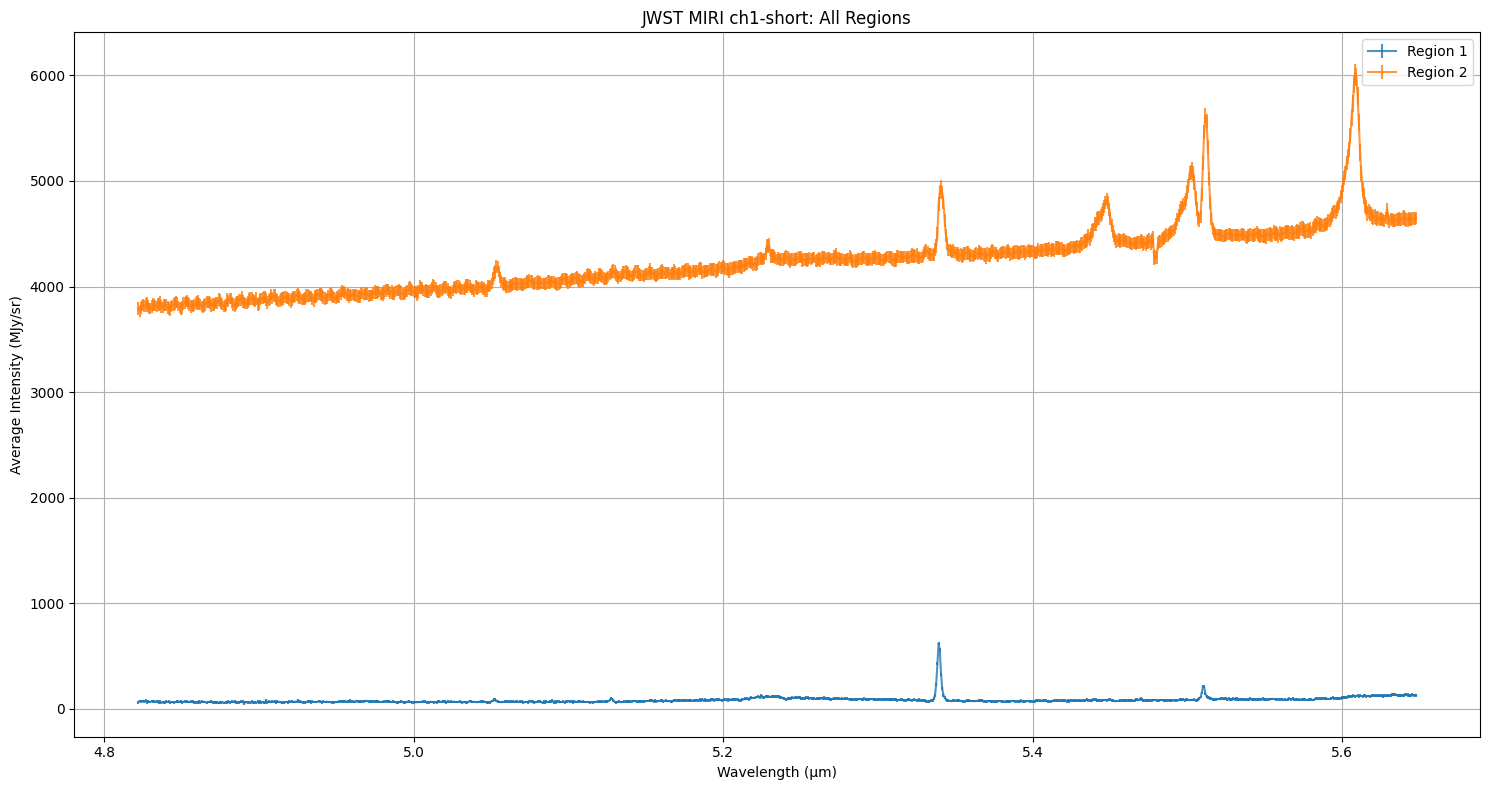

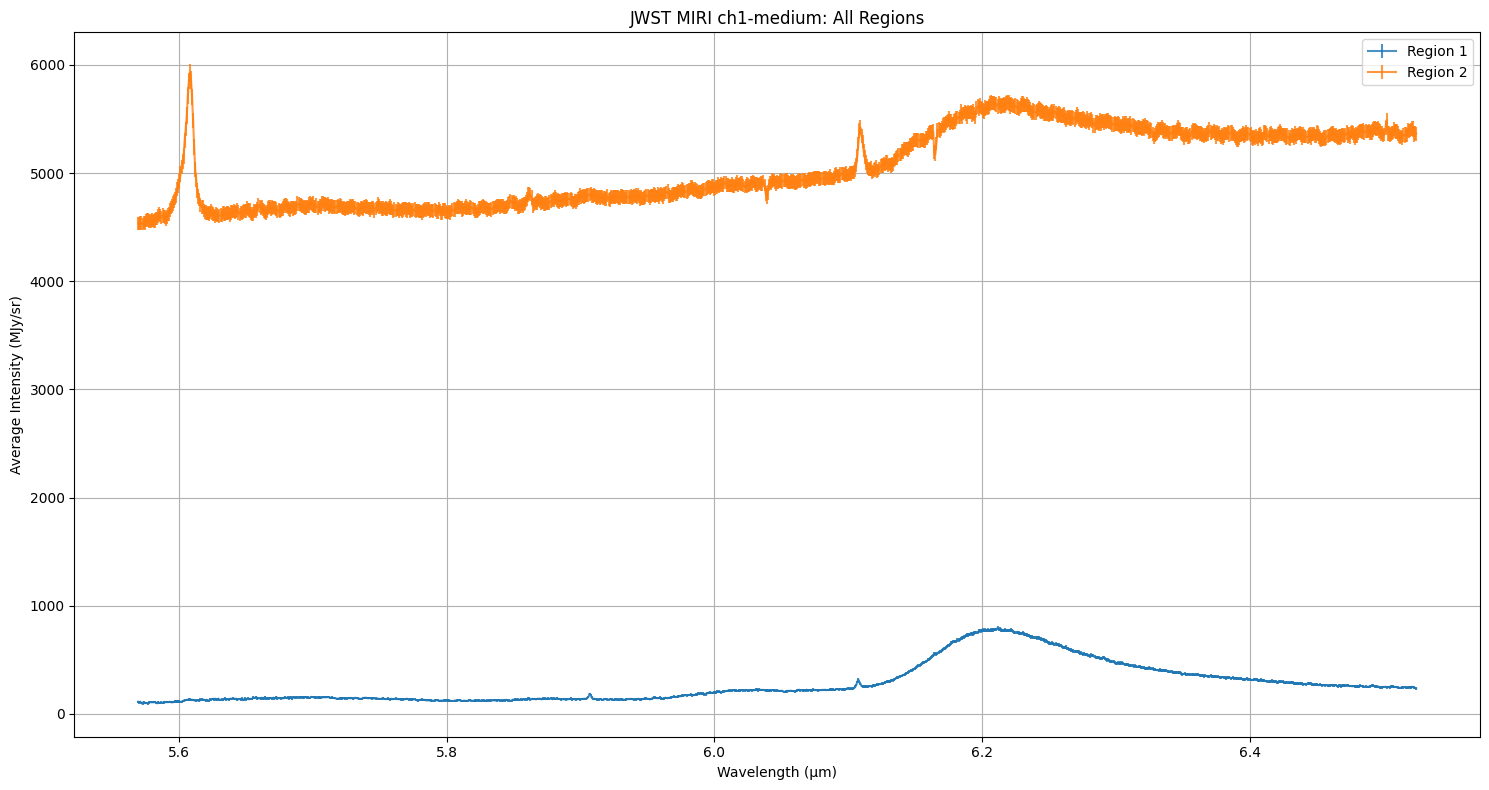

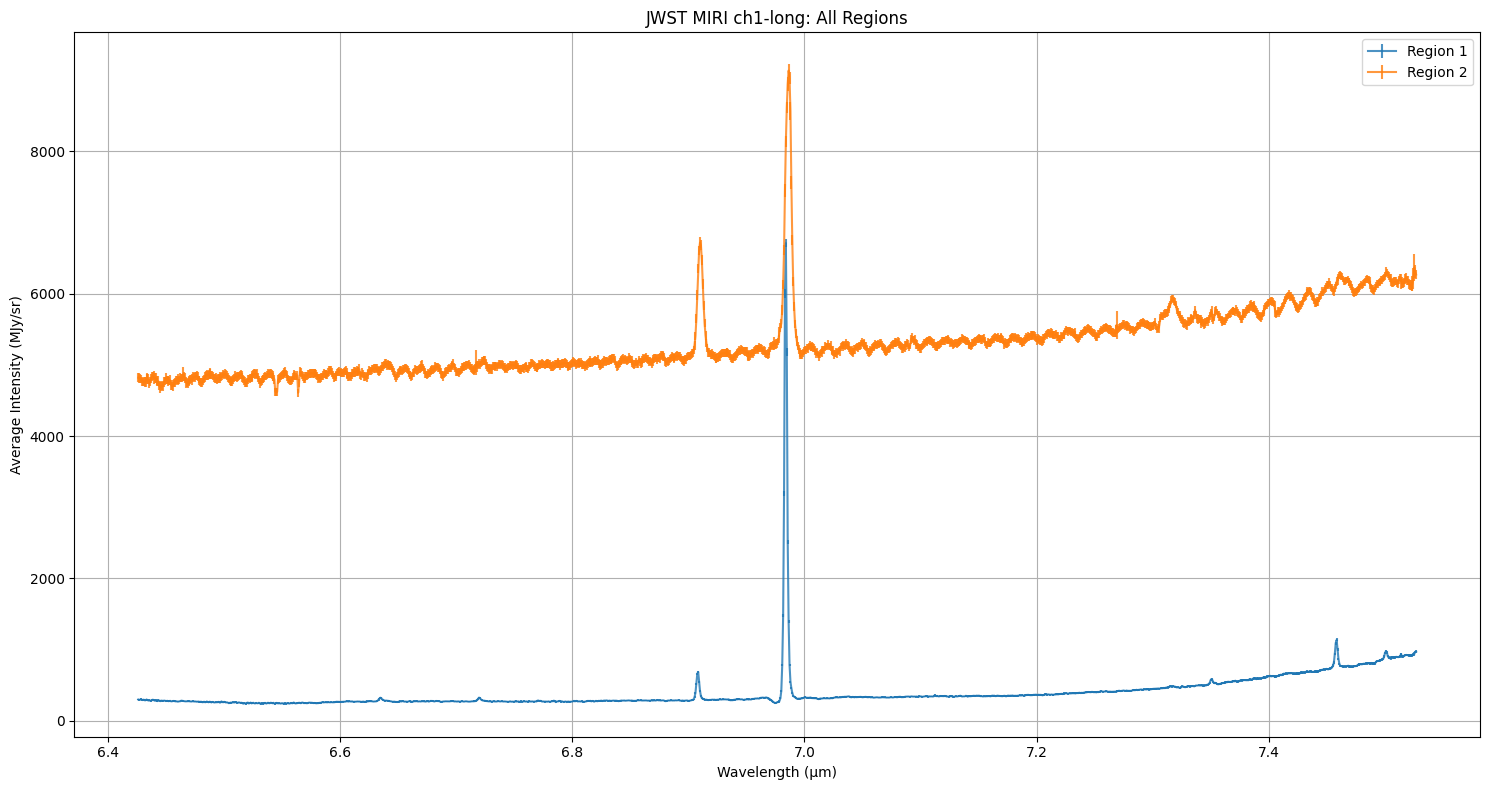

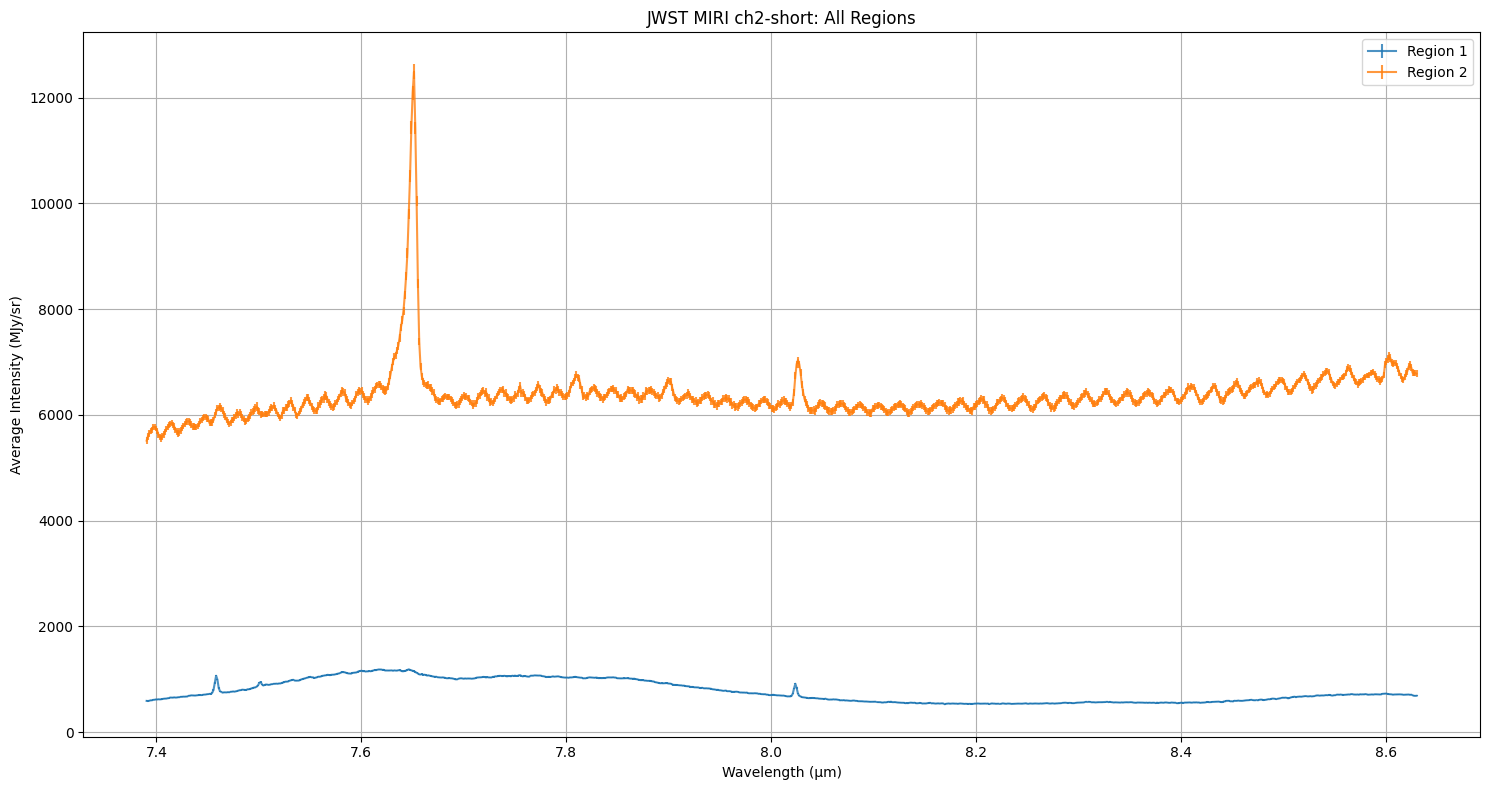

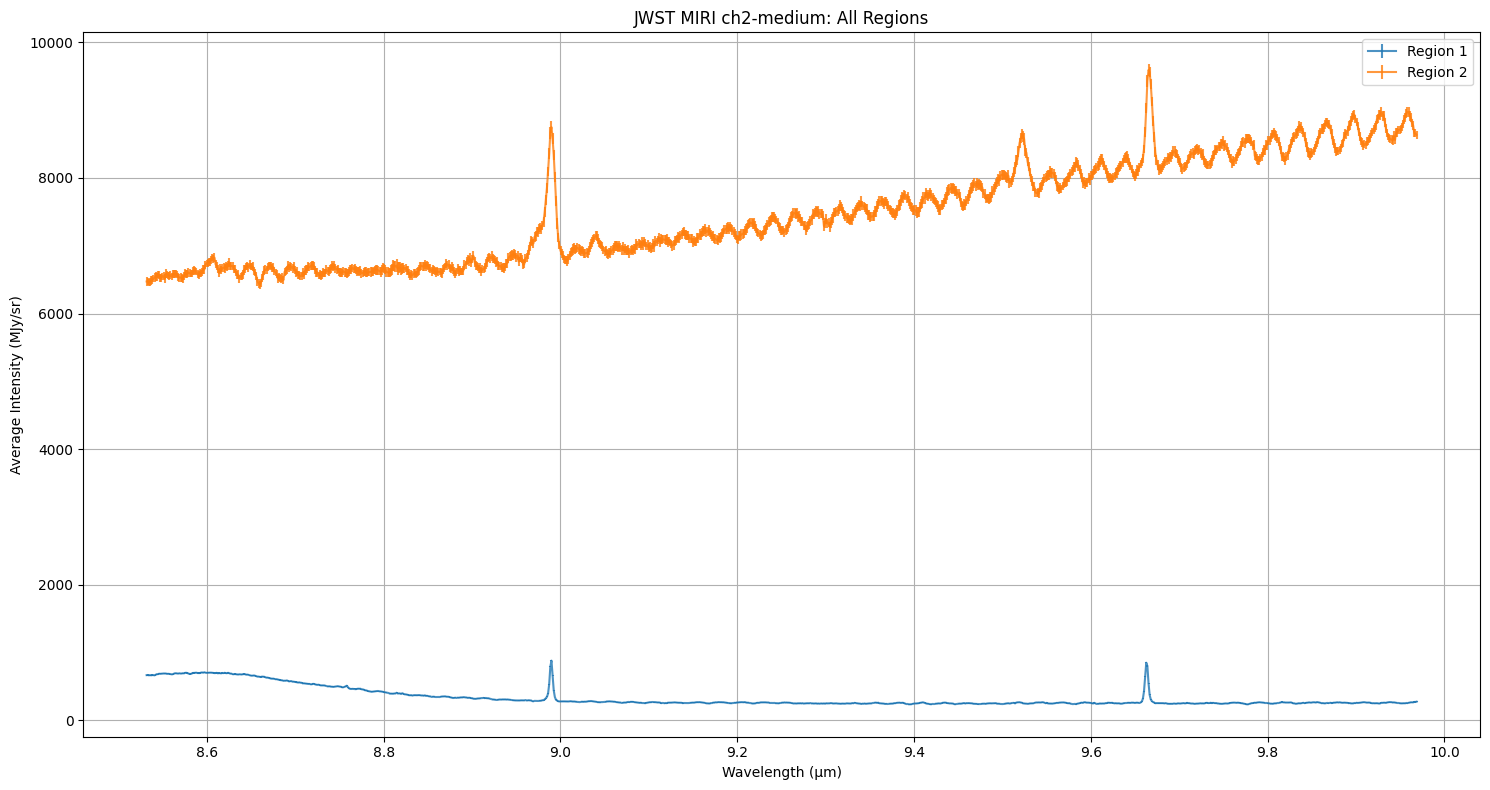

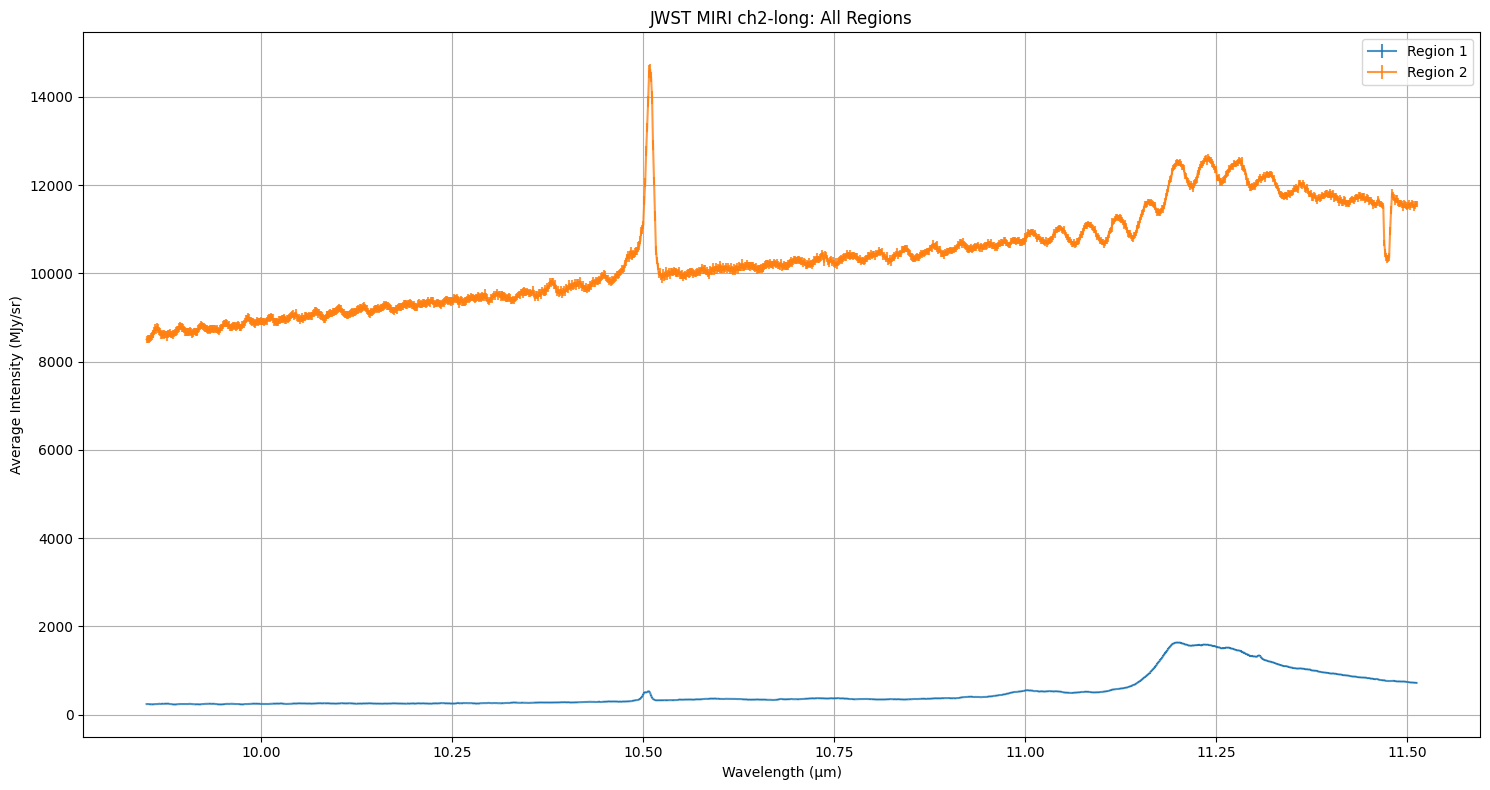

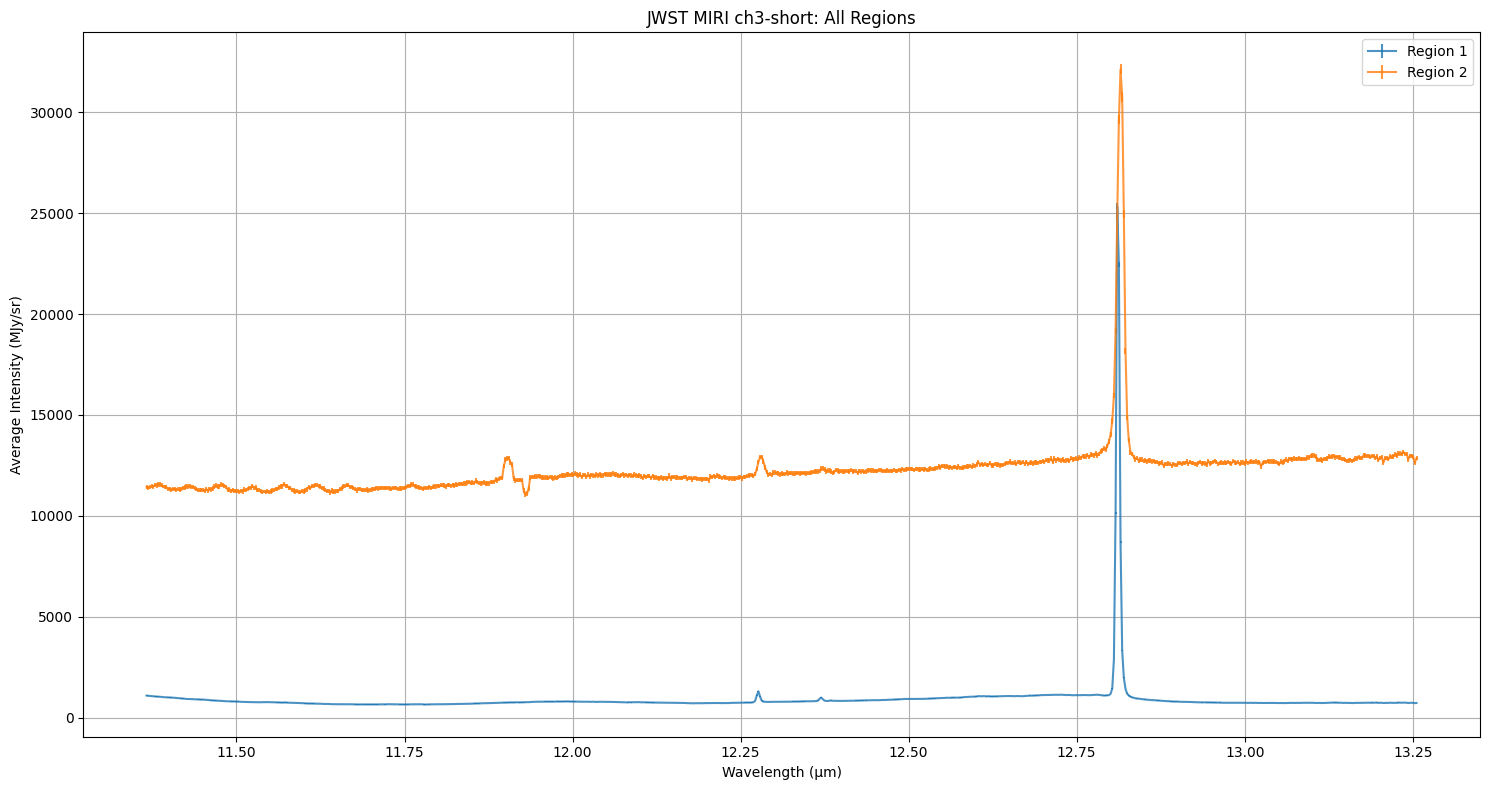

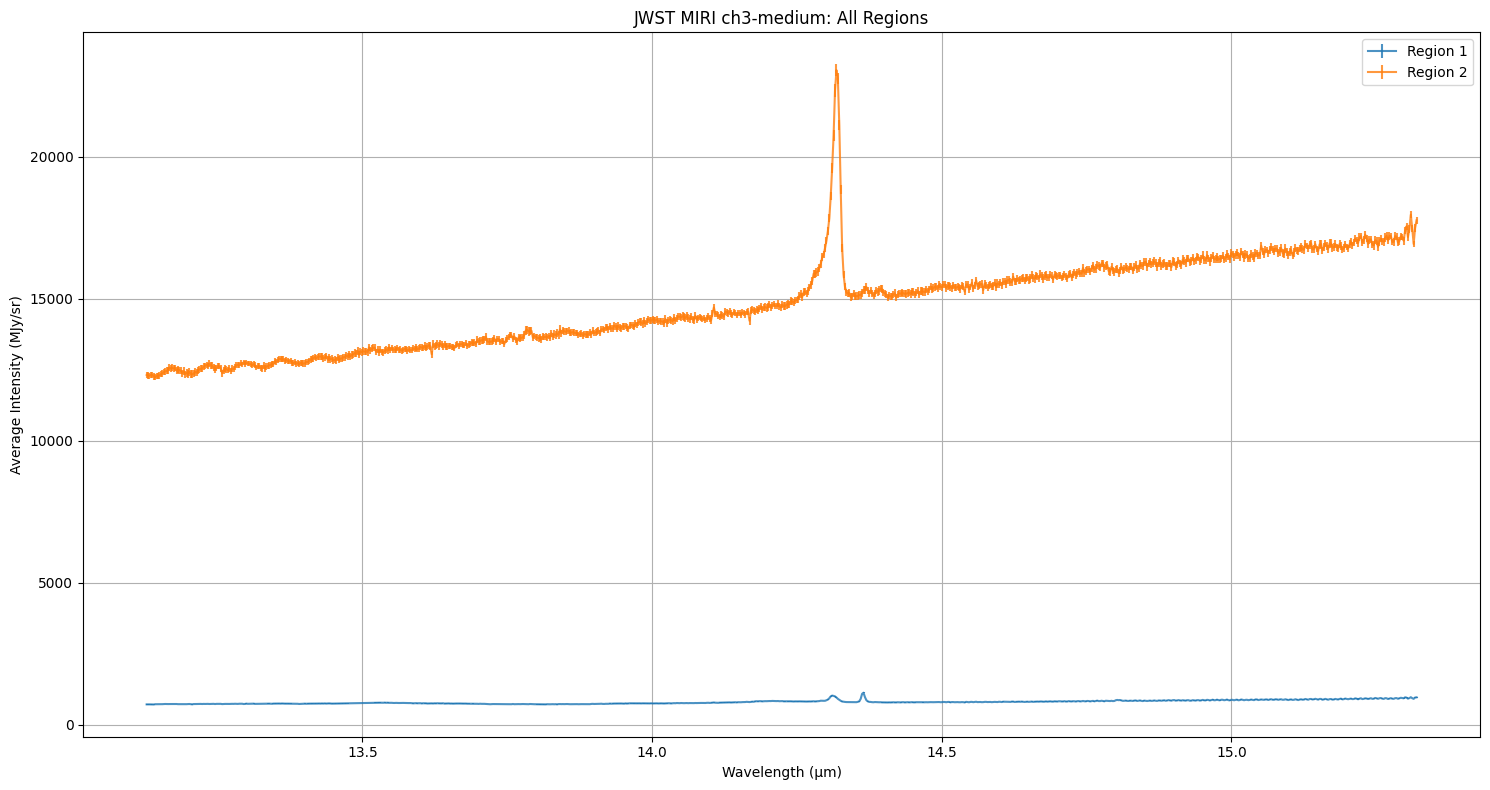

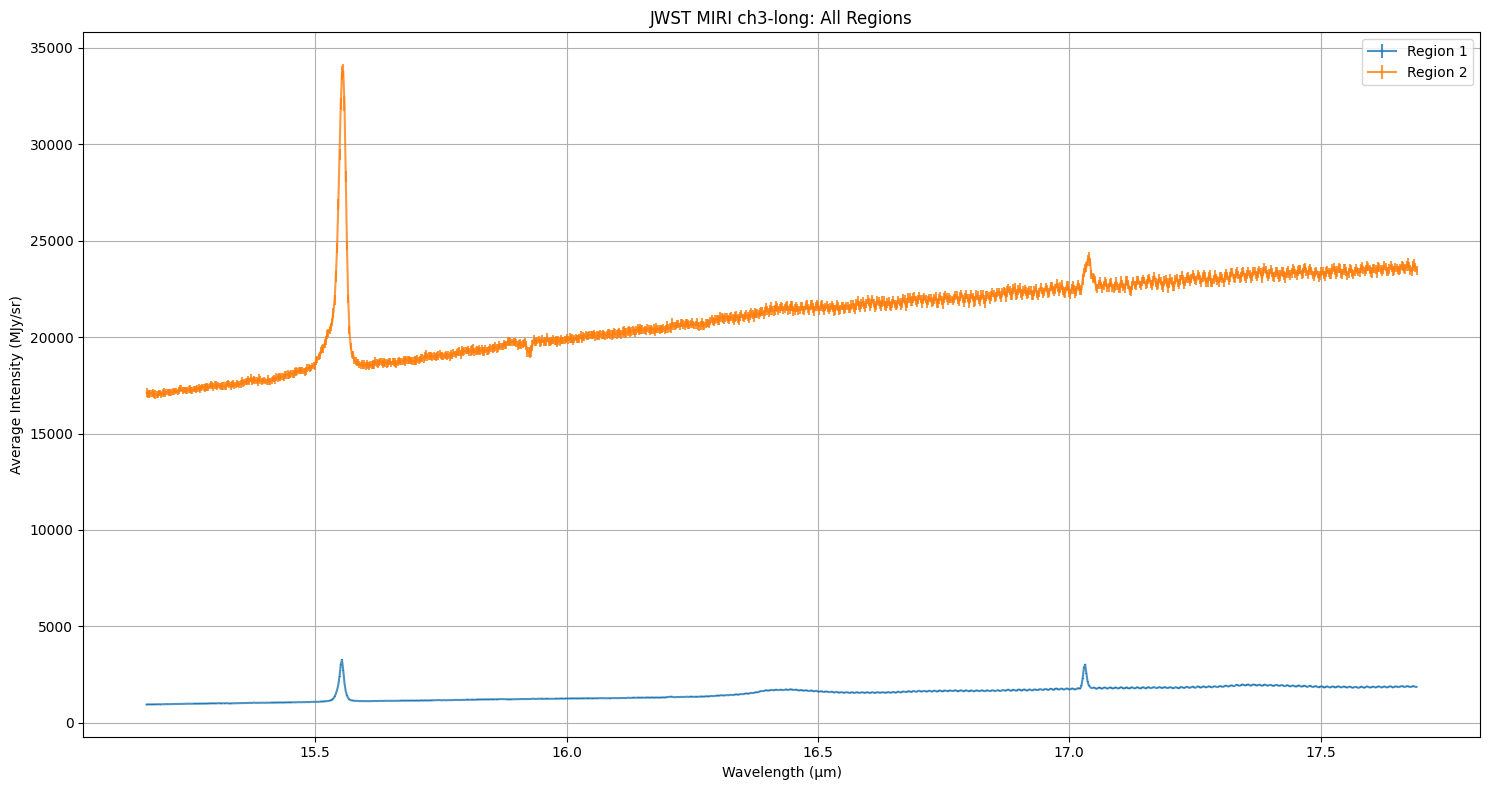

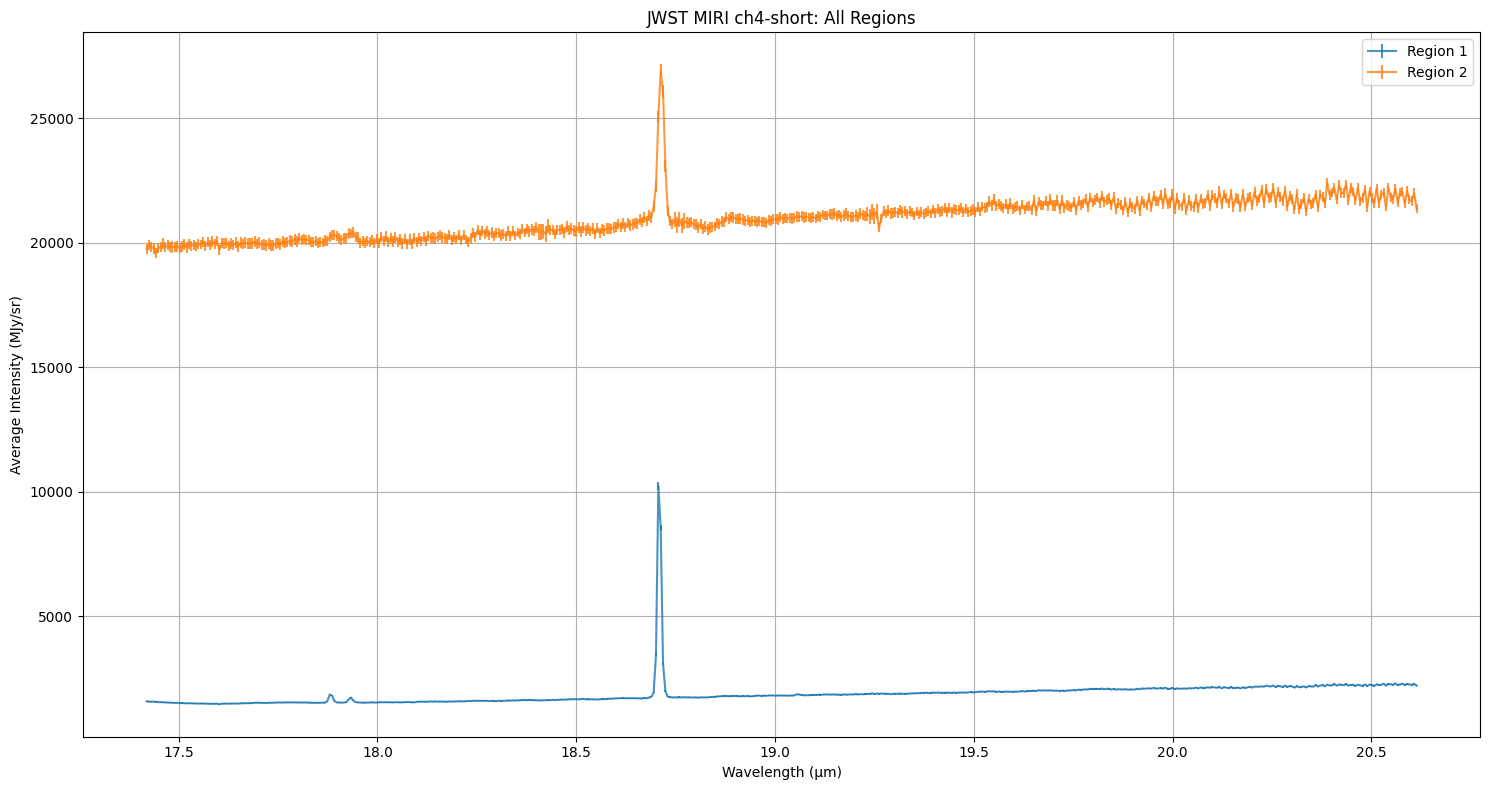

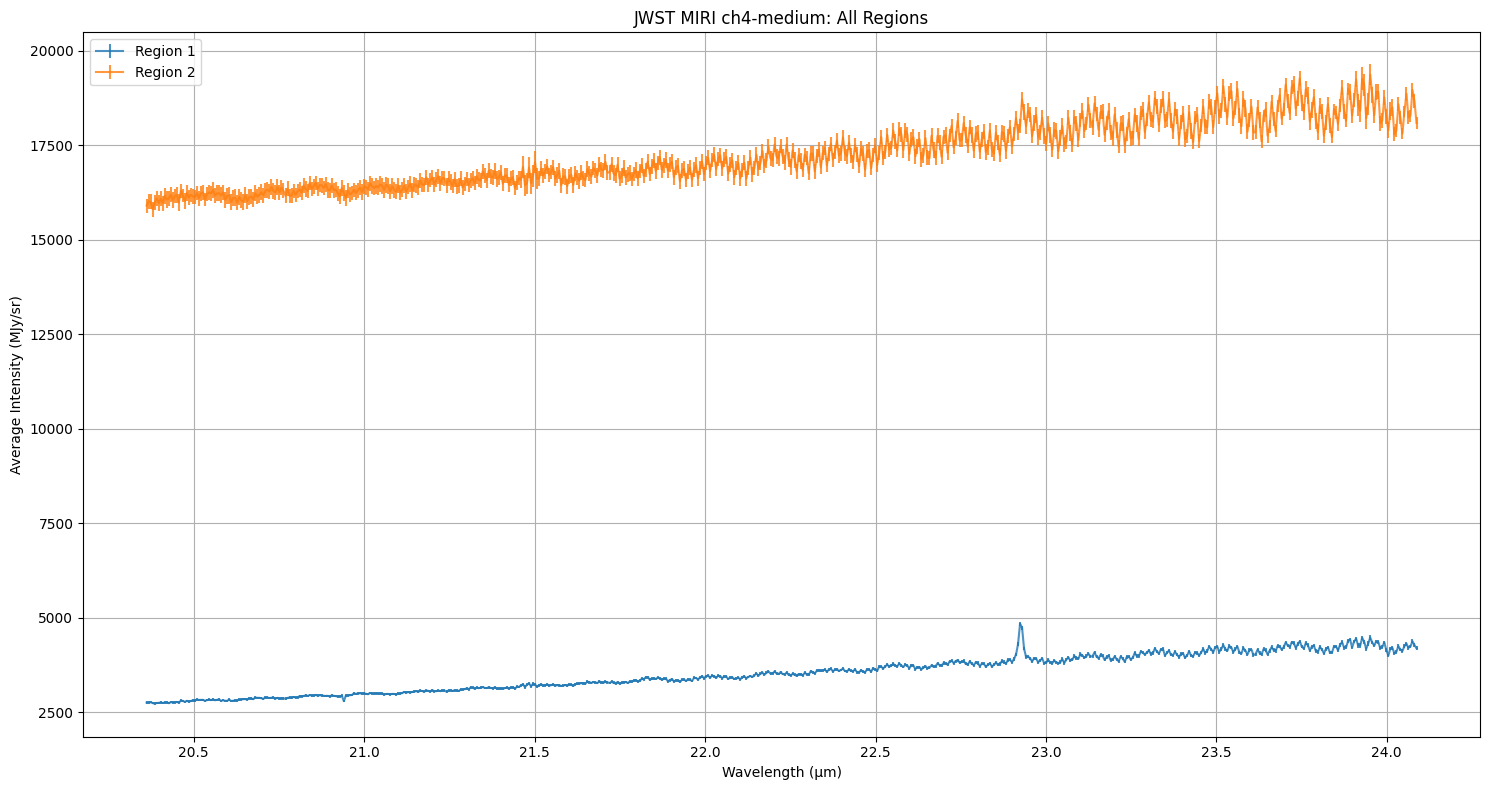

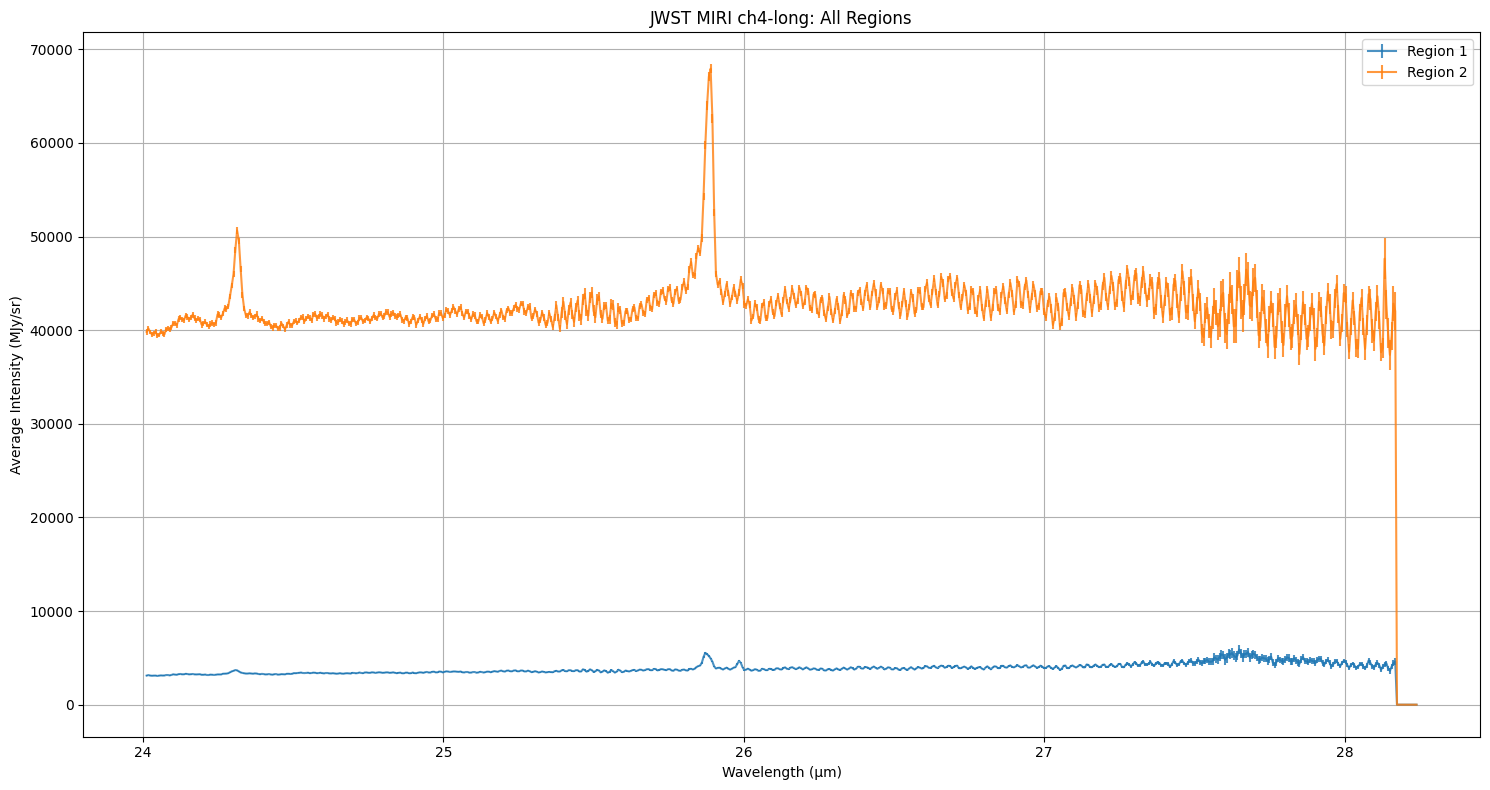

Pixel scale table saved to 'pixel_scale_table.csv'.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

channels = [1, 2, 3, 4]
parts = ['short', 'medium', 'long']
num_regions = len(regions)  

for ch_num in channels:
    for part in parts:
        ch_part = f'ch{ch_num}-{part}'
        plt.figure(figsize=(15, 8))
        for region_idx in range(num_regions):
            csv_file = f'spectrum_{ch_part}_region_{region_idx+1}.csv'
            df = pd.read_csv(csv_file)
            plt.errorbar(df['wavelength'], df['intensity'], yerr=df['intensity_err'],
                         label=f'Region {region_idx+1}', alpha=0.8)
        plt.xlabel('Wavelength (μm)')
        plt.ylabel('Average Intensity (MJy/sr)')
        plt.title(f'JWST MIRI {ch_part}: for all given Regions')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

pixel_scale_df = pd.DataFrame(pixel_scale_table)
pixel_scale_df.to_csv('pixel_scale_table.csv', index=False)
print("Pixel scale table saved to 'pixel_scale_table.csv'.")


### **Analysis:**

- #### **A vertical shift between spectra may be observed due to calibration and we can ignore it for feature comparison.**
- #### **Region 1 (nucleus/AGN) typically shows stronger high-ionization lines ([Ne V], [O IV]), while Region 2 (starburst ring) shows stronger PAH features and low-ionization lines ([Ne II], [S III]).**
- #### **The differences observed reflect the dominance of AGN or starburst activity and differences in dust and gas properties.**

# 8. Overlay Known MIR Emission Lines

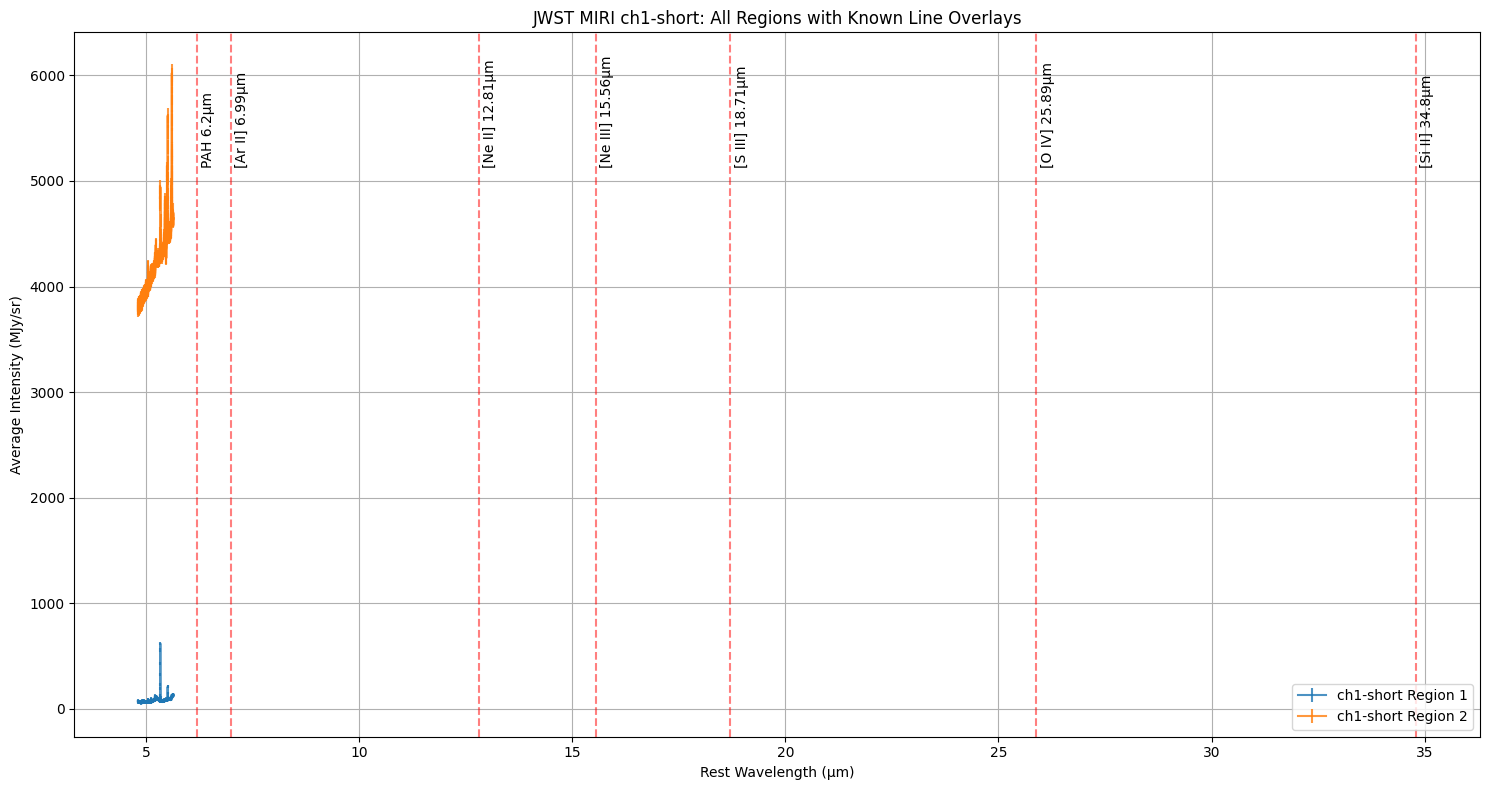

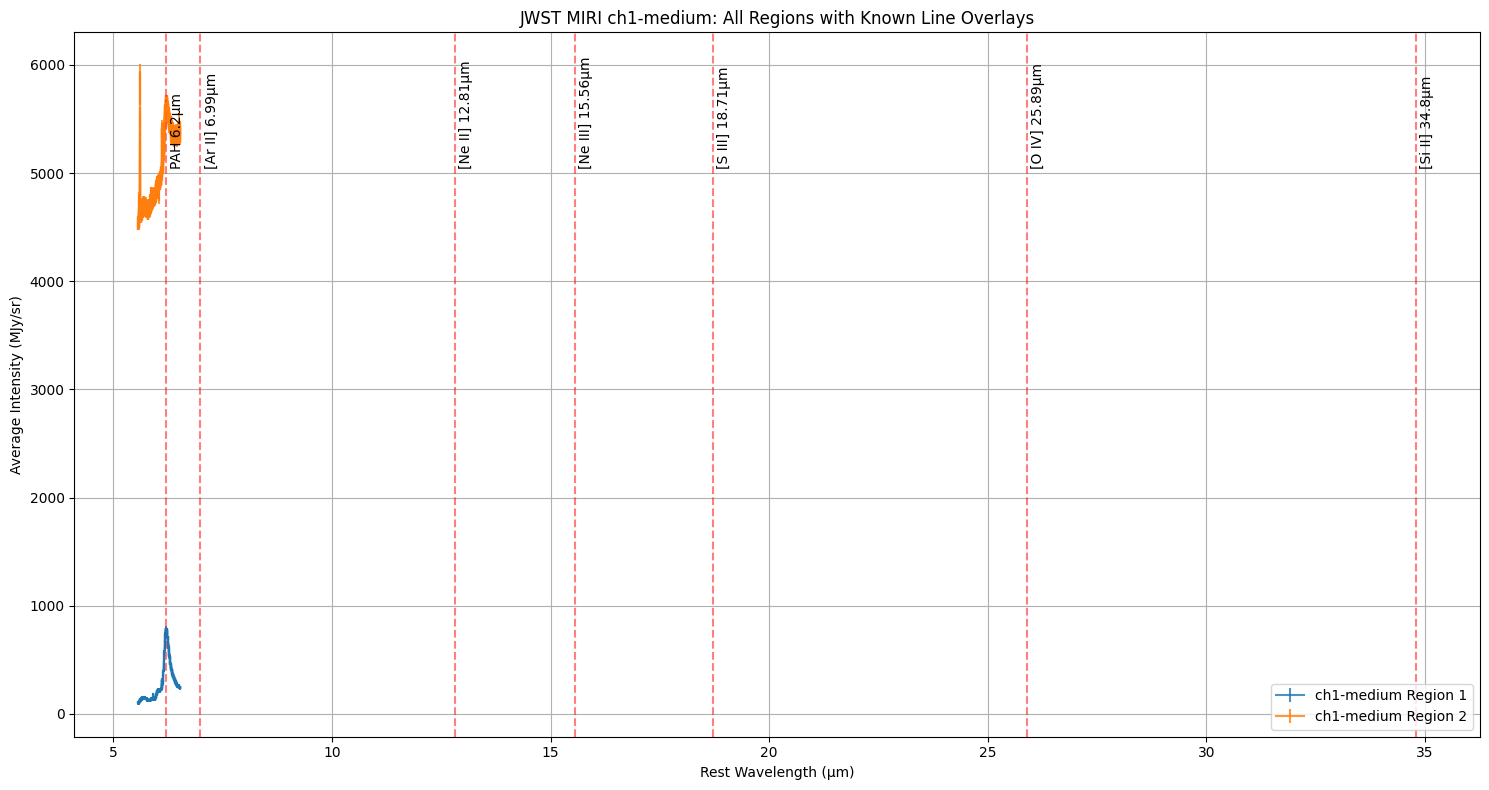

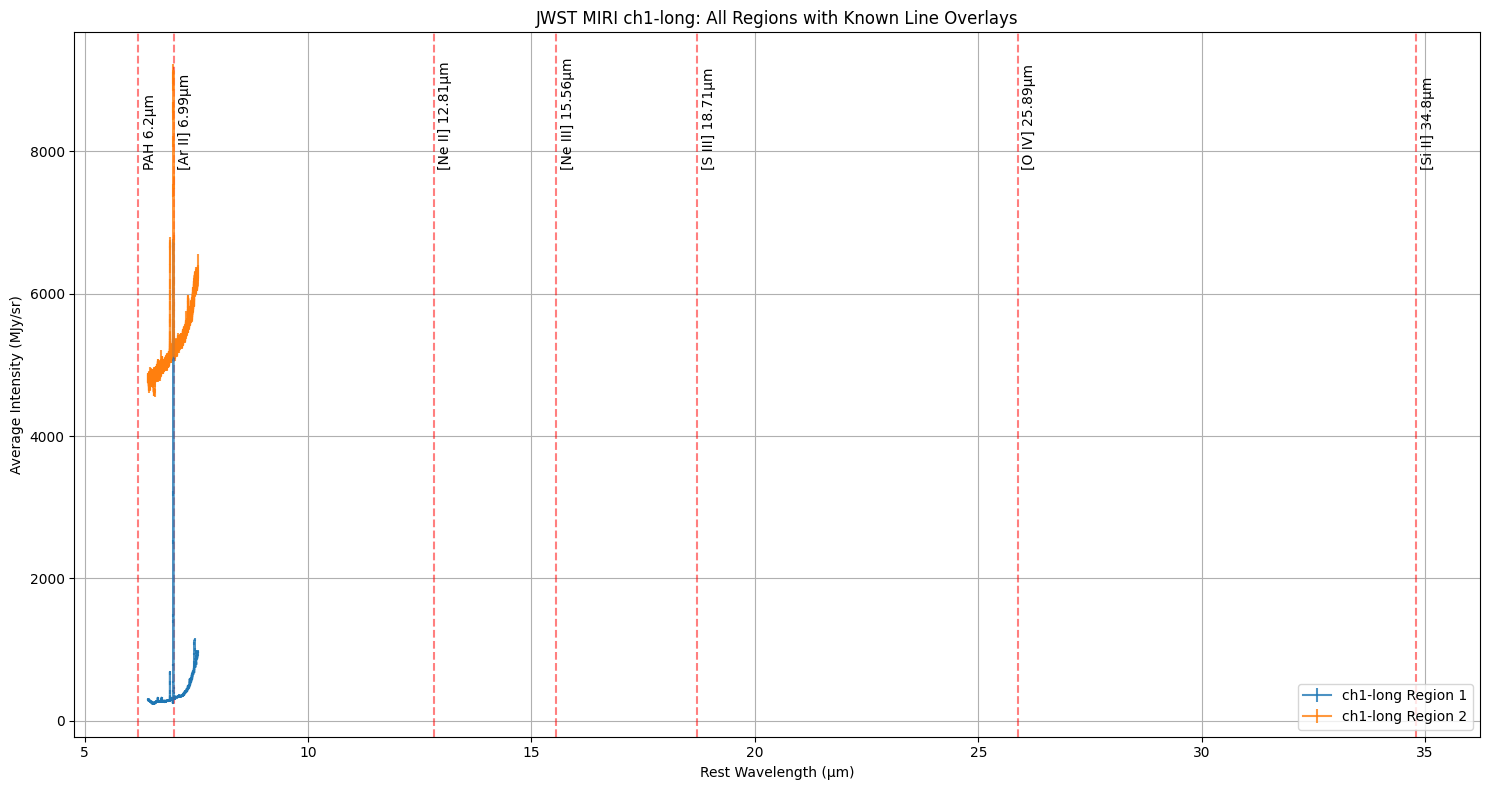

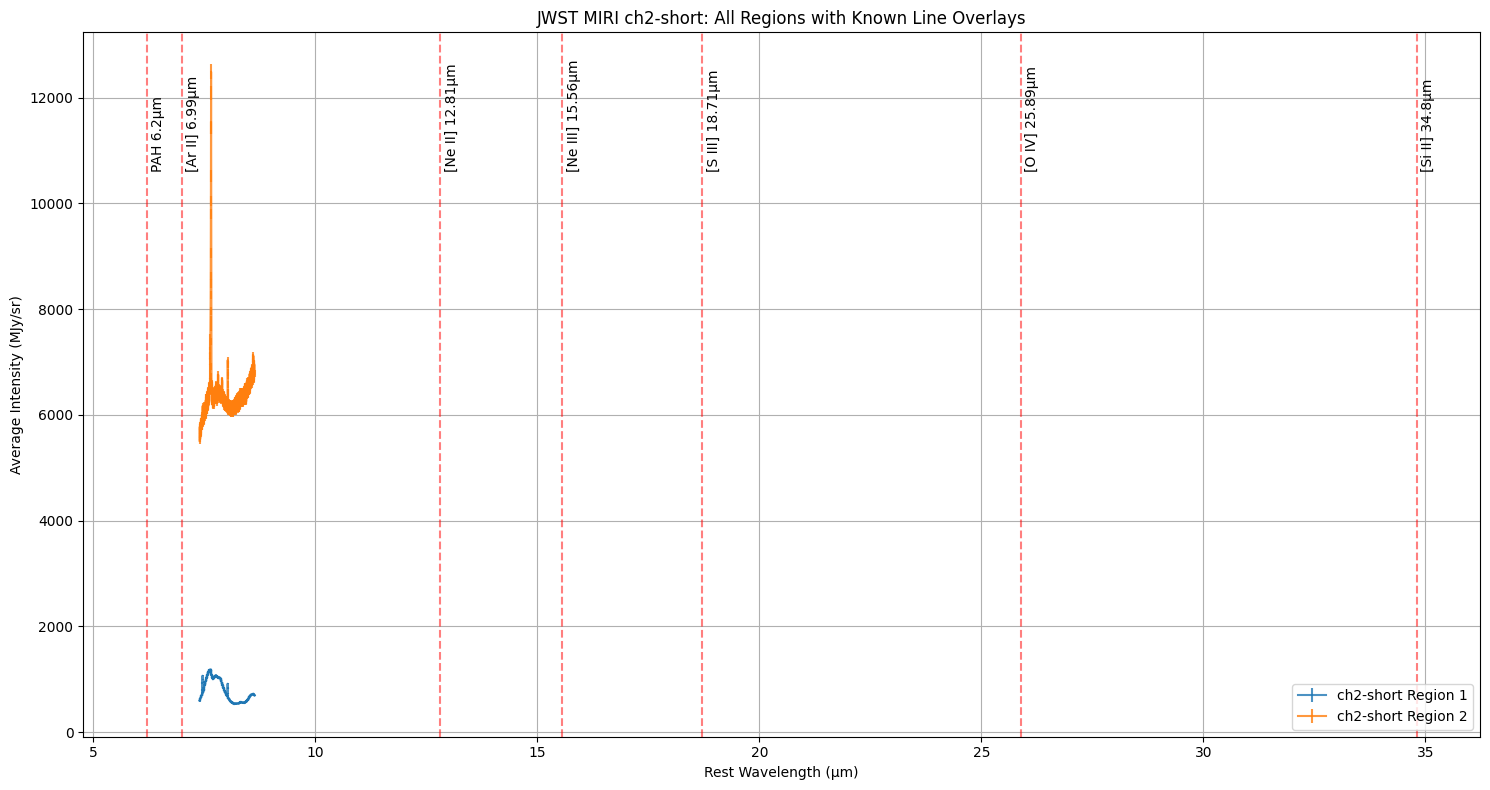

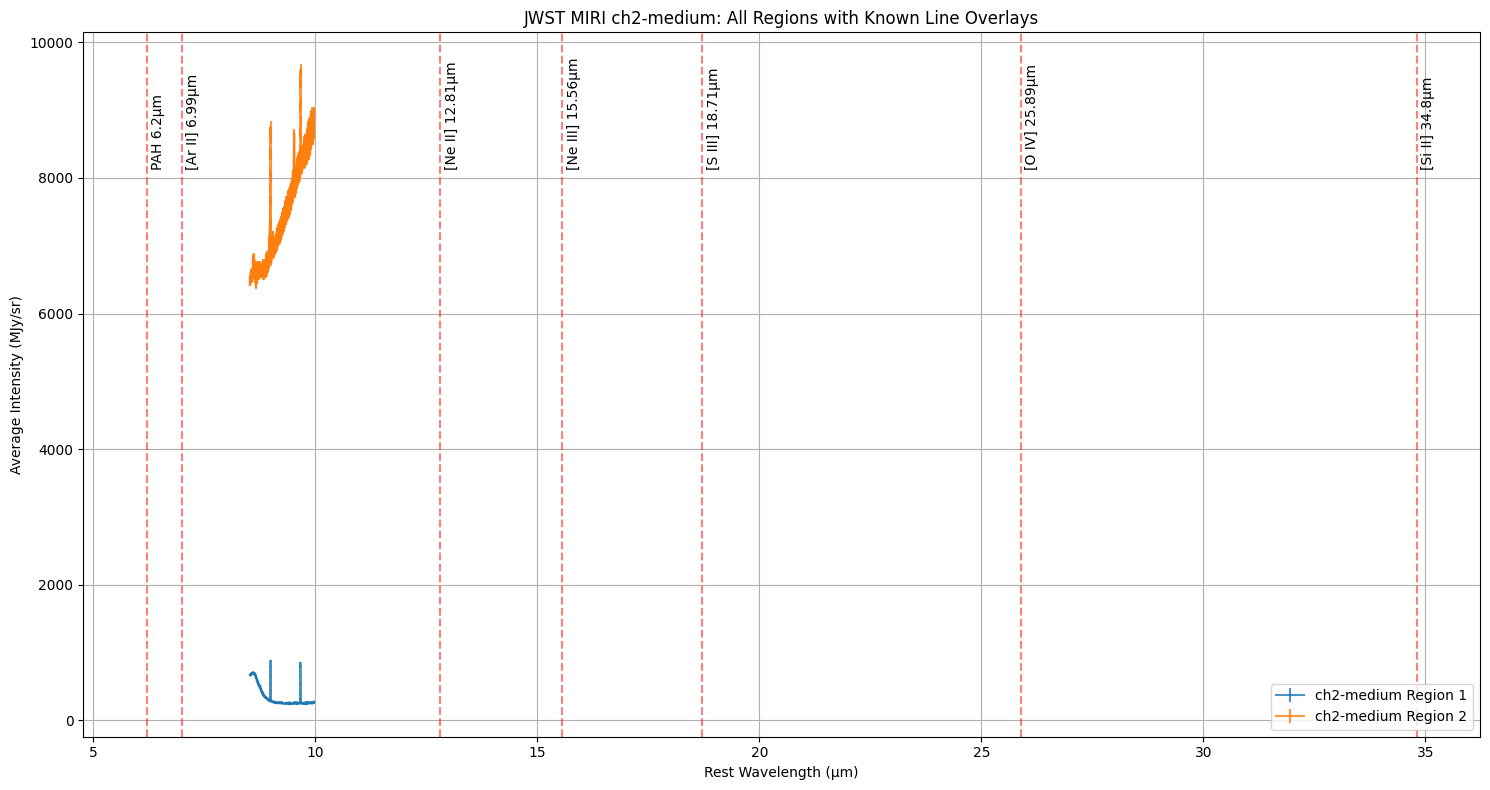

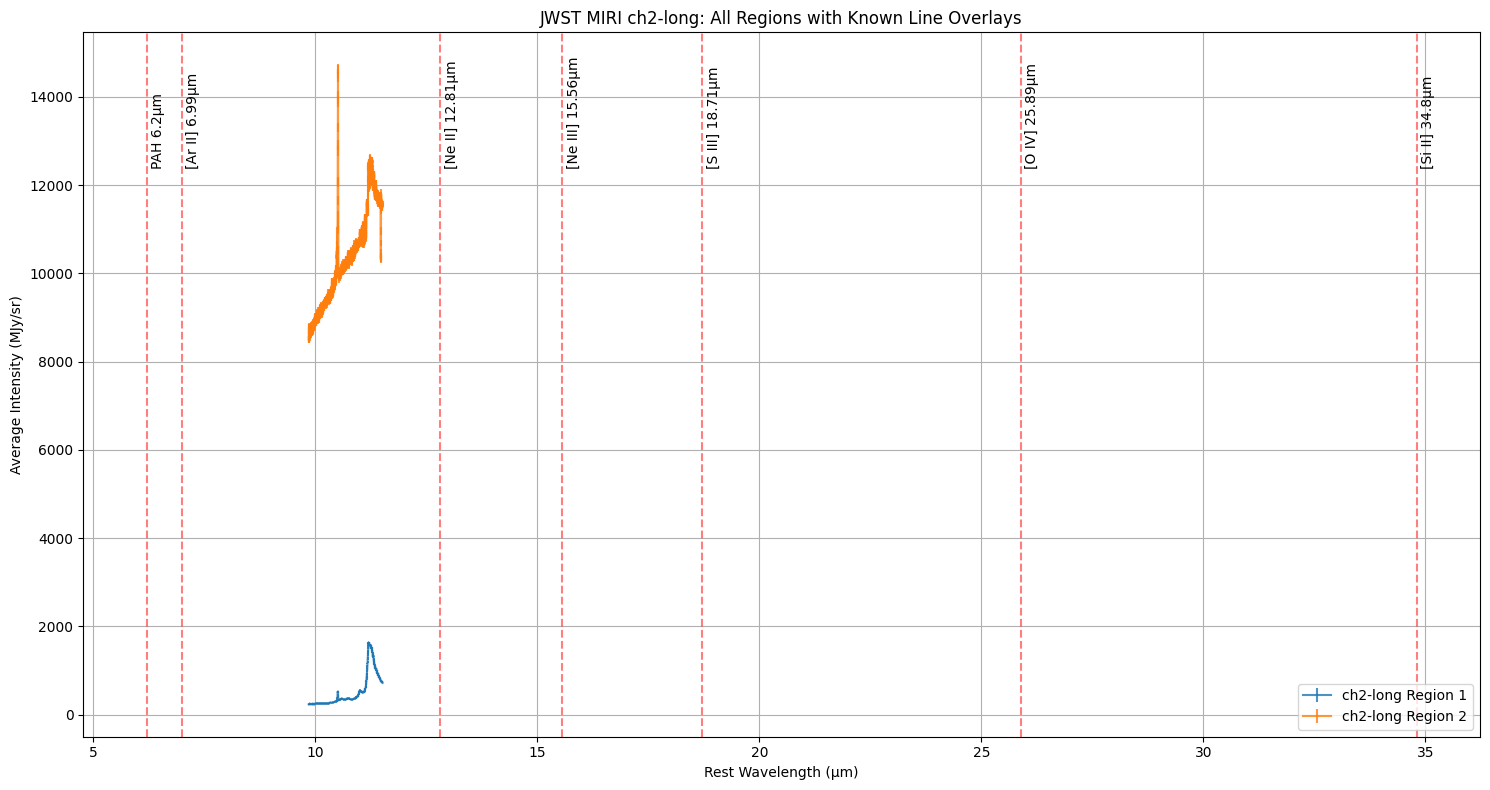

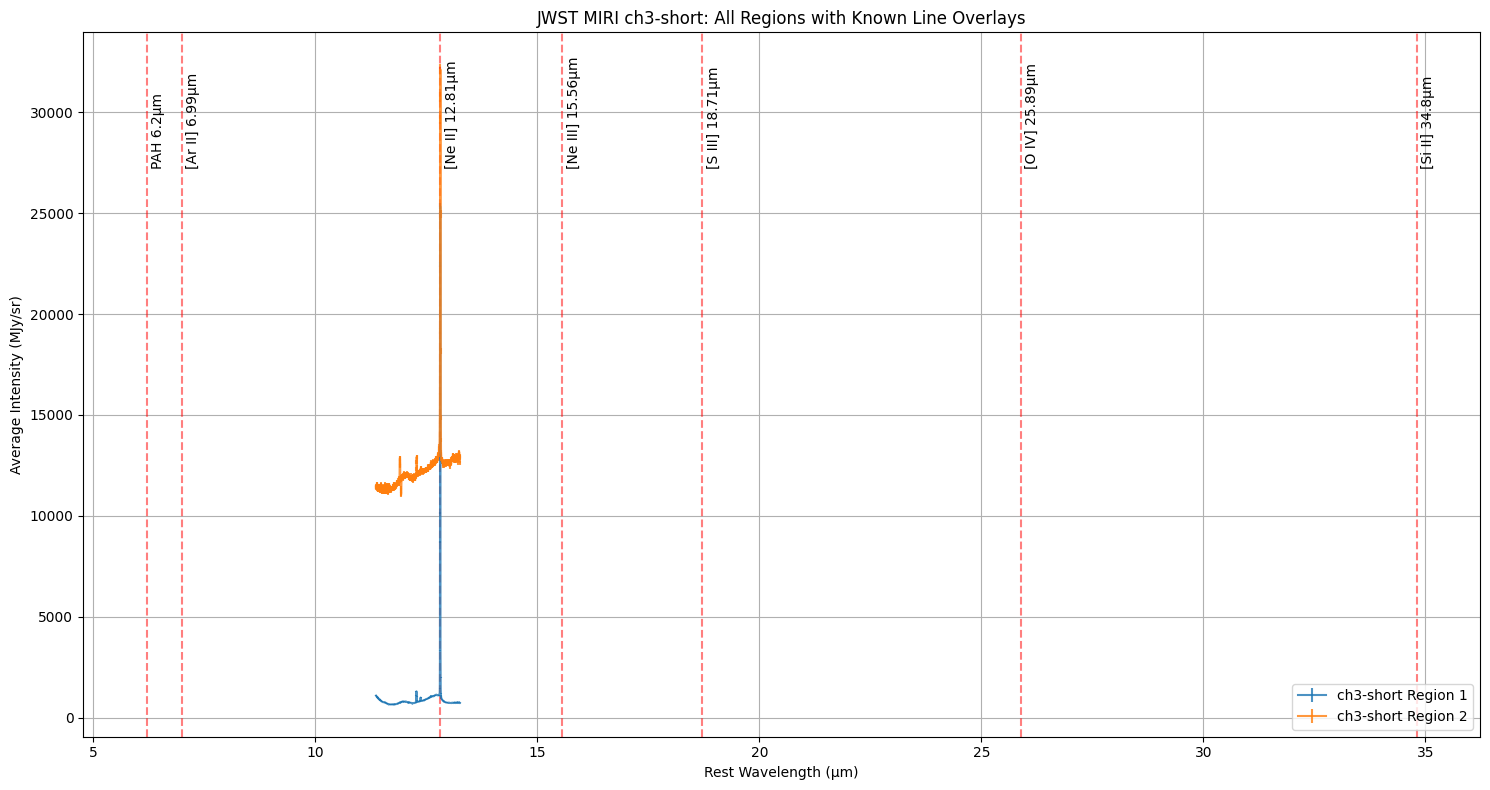

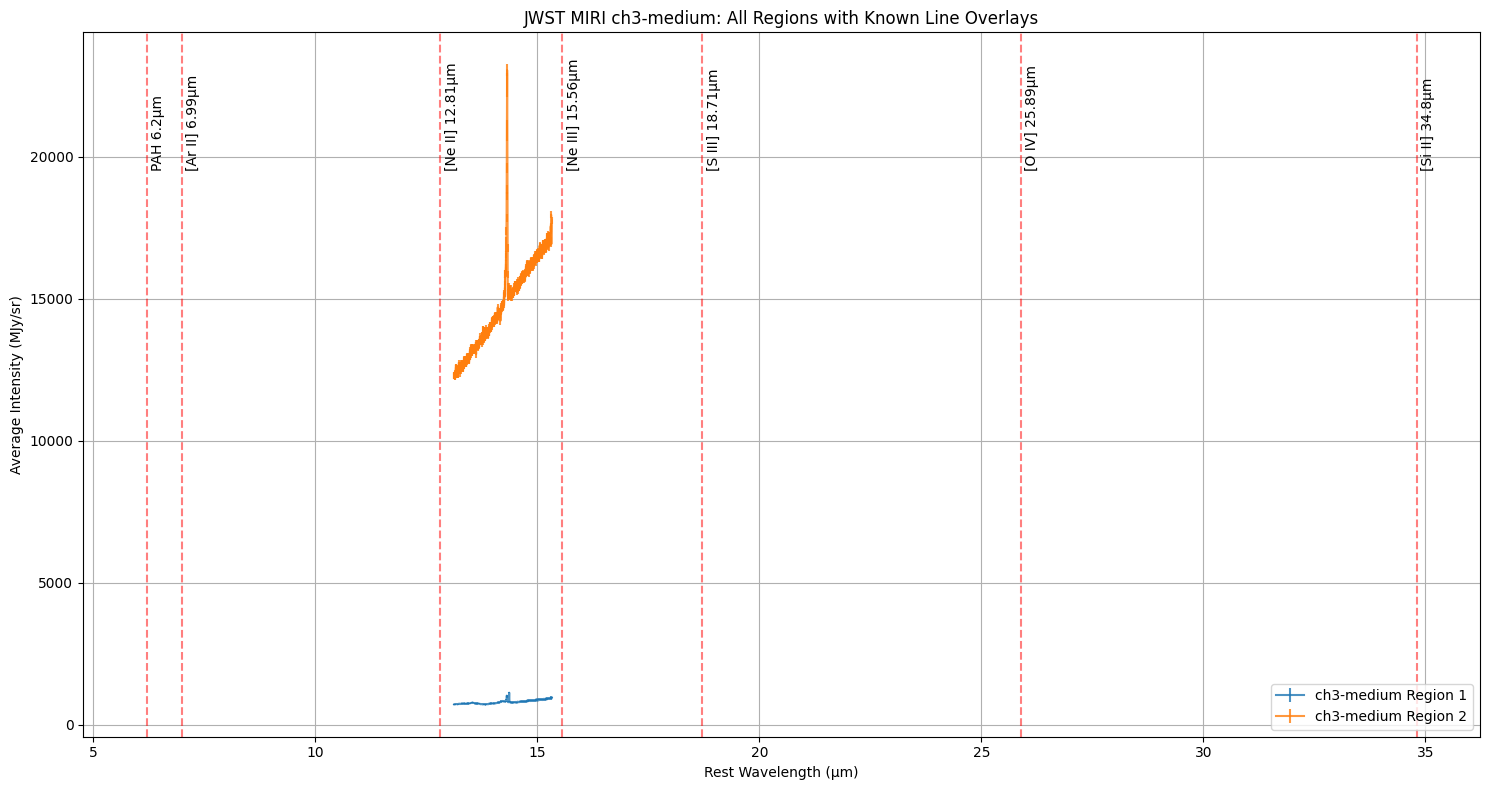

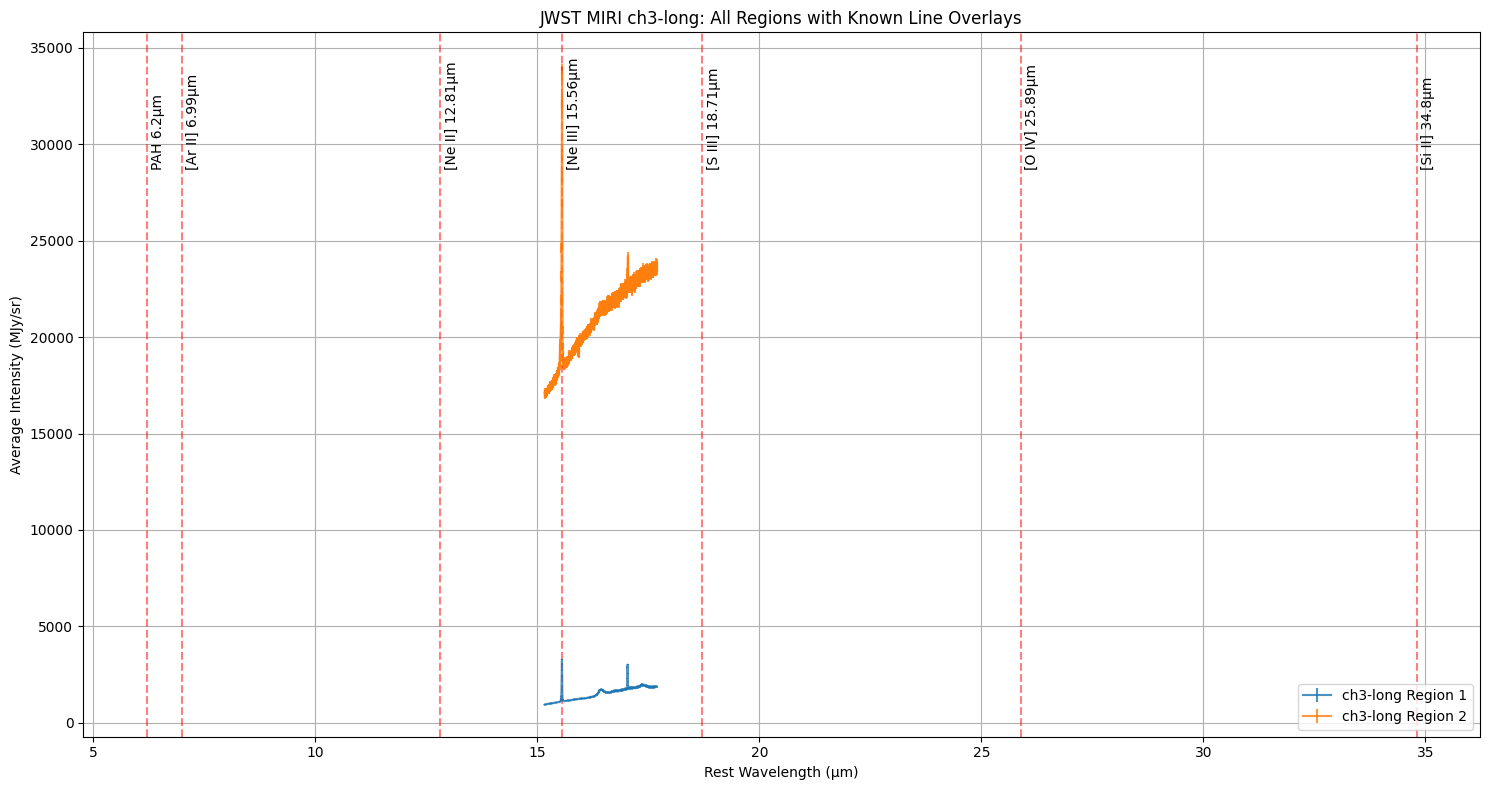

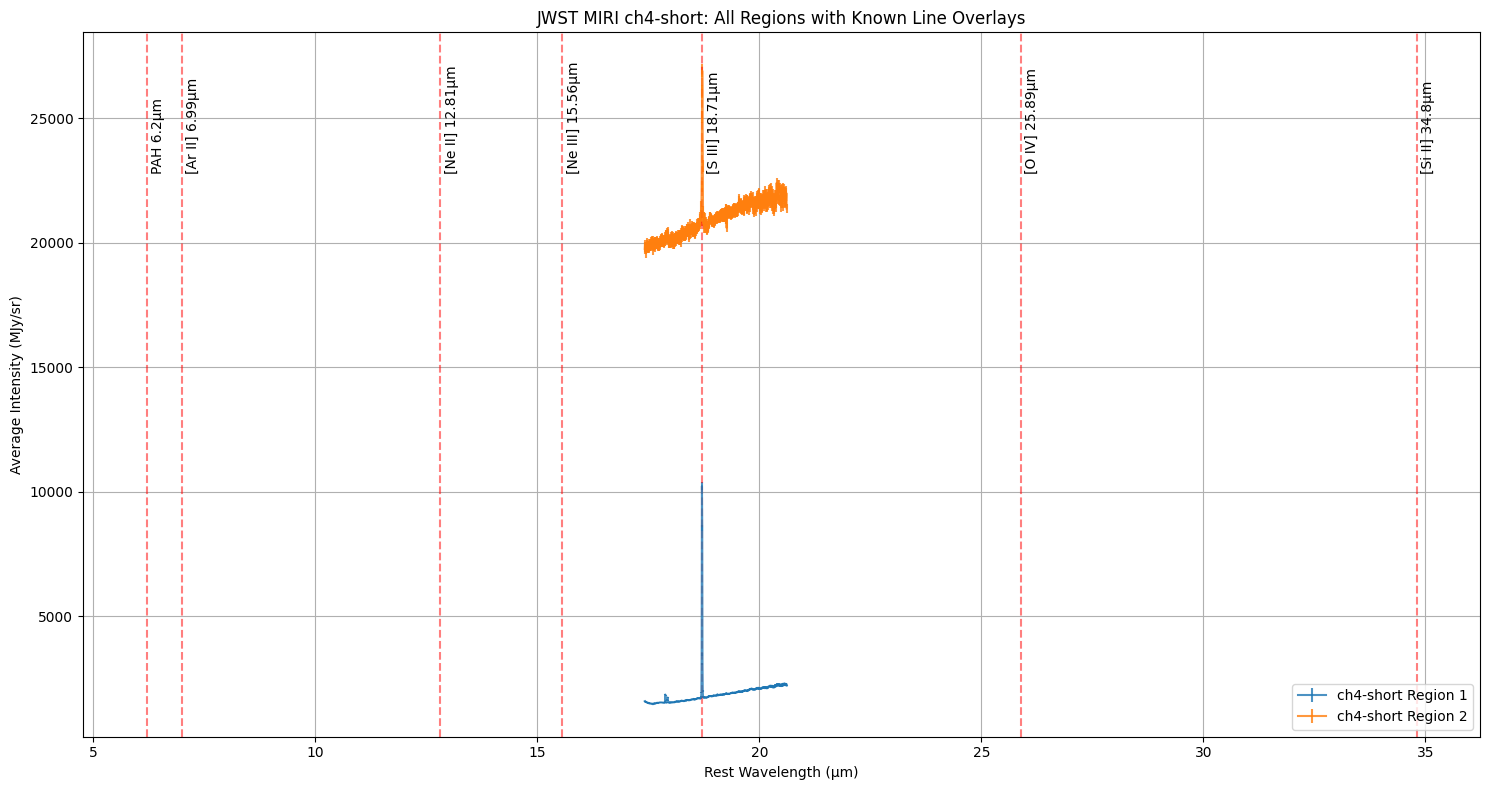

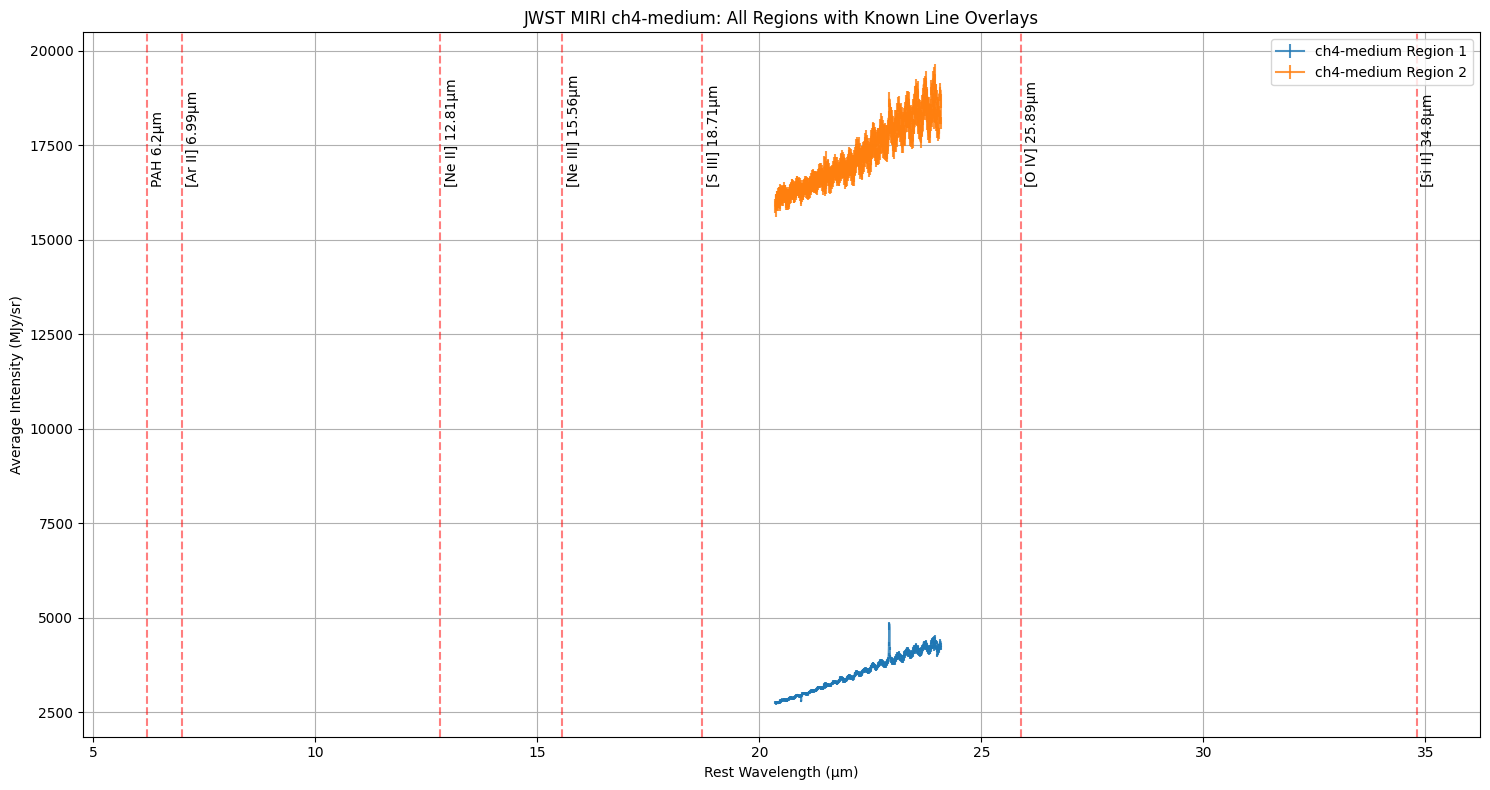

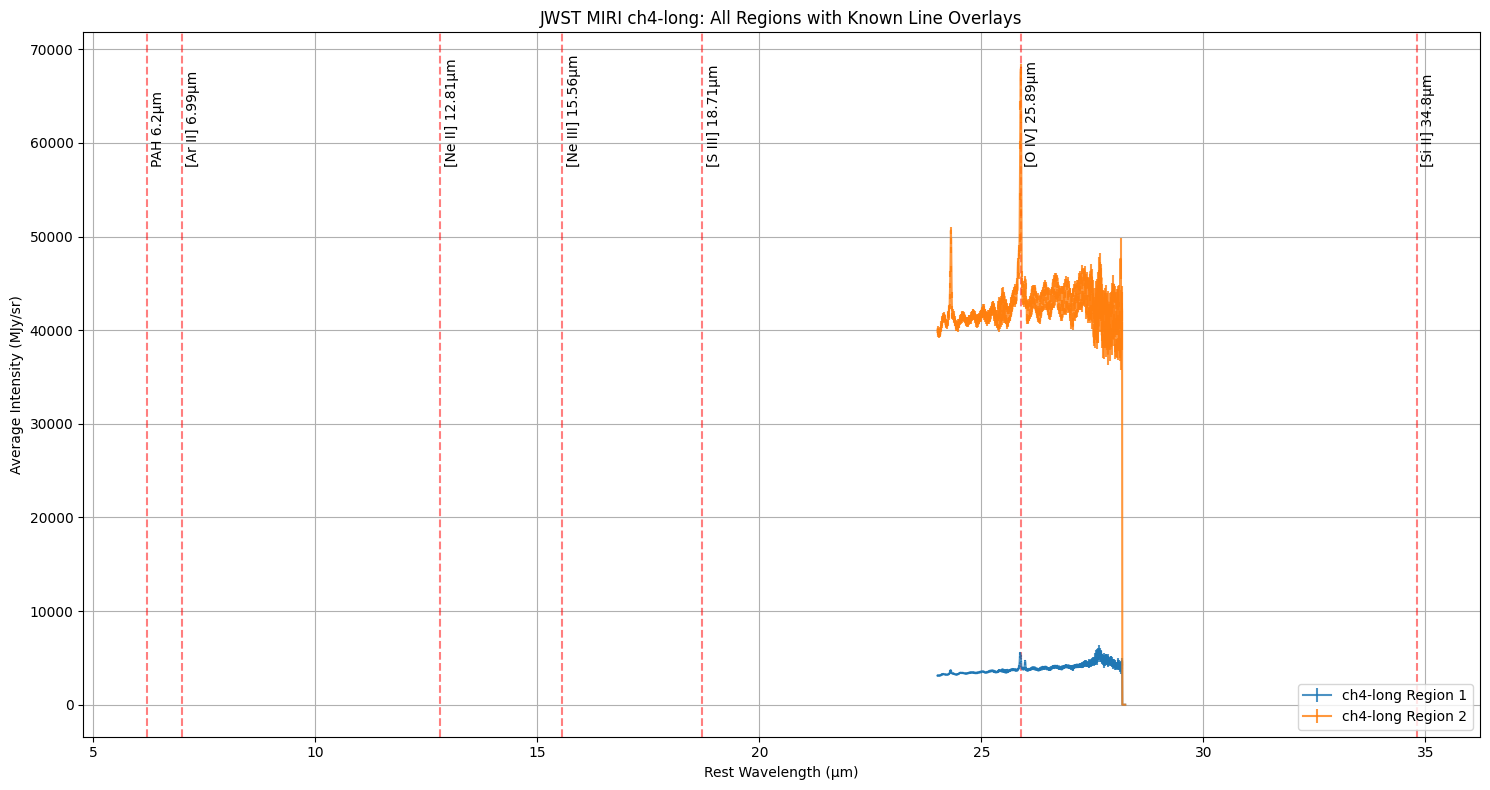

In [ ]:
known_lines = {
    "PAH 6.2µm": 6.2,
    "[Ar II] 6.99µm": 6.99,
    "[Ne II] 12.81µm": 12.81,
    "[Ne III] 15.56µm": 15.56,
    "[S III] 18.71µm": 18.71,
    "[O IV] 25.89µm": 25.89,
    "[Si II] 34.8µm": 34.8,
}

for ch_num in channels:
    for part in parts:
        ch_part = f'ch{ch_num}-{part}'
        plt.figure(figsize=(15, 8))
        for region_idx in range(1, len(regions)+1):
            csv_file = f'spectrum_{ch_part}_region_{region_idx}.csv'
            df = pd.read_csv(csv_file)
            plt.errorbar(df['wavelength'], df['intensity'], yerr=df['intensity_err'],
                         label=f'{ch_part} Region {region_idx}', alpha=0.8)
        for label, line_wavelength in known_lines.items():
            plt.axvline(line_wavelength, color='red', linestyle='--', alpha=0.5)
            plt.text(line_wavelength + 0.1, plt.ylim()[1]*0.8, label, rotation=90, verticalalignment='bottom', fontsize=10)
        plt.xlabel('Rest Wavelength (μm)')
        plt.ylabel('Average Intensity (MJy/sr)')
        plt.title(f'JWST MIRI {ch_part}: for all given regions with known line overlays')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


# 9. Interactive Visualization 

In [ ]:
import plotly.graph_objects as go
import numpy as np

for ch_num in channels:
    for part in parts:
        ch_part = f'ch{ch_num}-{part}'
        fig = go.Figure()
        for region_idx in range(1, len(regions)+1):
            csv_file = f'spectrum_{ch_part}_region_{region_idx}.csv'
            df = pd.read_csv(csv_file)
            fig.add_trace(go.Scatter(
                x=df['wavelength'],
                y=df['intensity'],
                mode='lines',
                name=f'Region {region_idx}',
                error_y=dict(type='data', array=df['intensity_err'], visible=True),
                hovertemplate='λ: %{x:.3f} μm<br>Intensity: %{y:.2f} MJy/sr<extra></extra>'
            ))
            fig.add_trace(go.Scatter(
                x=np.concatenate([df['wavelength'], df['wavelength'][::-1]]),
                y=np.concatenate([df['intensity'] + df['intensity_err'], (df['intensity'] - df['intensity_err'])[::-1]]),
                fill='toself',
                fillcolor='rgba(31, 119, 180, 0.1)',
                line=dict(color='rgba(255,255,255,0)'),
                hoverinfo='skip',
                name=f'Region {region_idx} Uncertainty',
                showlegend=False
            ))
        for label, wl in known_lines.items():
            fig.add_vline(x=wl, line=dict(color='red', dash='dash'), annotation_text=label, annotation_position='top')
        fig.update_layout(
            title=f'NGC 7469 JWST/MIRI {ch_part}: Interactive Spectrum for all given regions',
            xaxis_title='Wavelength (μm)',
            yaxis_title='Intensity (MJy/sr)',
            hovermode='x unified'
        )
        fig.show()


# 10. Emission Feature Table
| Line Name (Transition)      | Wavelength (μm) | Astrophysical Significance         | Stronger In Region |
|----------------------------|-----------------|------------------------------------|--------------------|
| PAH 6.2 (C–C stretch)      | 6.2             | Star formation, PAH emission       | Starburst ring     |
| [Ar II] 6.99               | 6.99            | H II regions, star formation       | Starburst ring     |
| PAH 7.7 (C–C stretch)      | 7.7             | Star formation, PAH emission       | Starburst ring     |
| PAH 8.6 (C–H in-plane)     | 8.6             | Star formation, PAH emission       | Starburst ring     |
| H₂ S(4)                    | 8.03            | Warm molecular gas                 | Both               |
| [Ar III] 8.99              | 8.99            | Ionized gas, young stars           | Starburst ring     |
| H₂ S(3)                    | 9.66            | Warm molecular gas                 | Both               |
| [S IV] 10.51               | 10.51           | High-excitation, AGN/starburst     | Nucleus            |
| PAH 11.3 (C–H out-plane)   | 11.3            | Star formation, PAH emission       | Starburst ring     |
| [Ne II] 12.81              | 12.81           | Star formation, H II regions       | Starburst ring     |
| [Ne V] 14.32               | 14.32           | AGN ionization, hard radiation     | Nucleus            |
| [Ne III] 15.56             | 15.56           | Higher ionization, AGN/starburst   | Nucleus            |
| [S III] 18.71              | 18.71           | Star formation, H II regions       | Starburst ring     |
| [O IV] 25.89               | 25.89           | AGN ionization, hard radiation     | Nucleus            |
| [Si II] 34.8               | 34.8            | PDRs, star formation               | Starburst ring     |


# 11. Channel-wise and Physical Analysis

- ### **Channel-wise Variations:** 

#### **As you move from Channel 1 to Channel 4, the number and prominence of spectral features change. PAH features dominate at shorter wavelengths, while atomic lines and continuum increase at longer wavelengths.The signal is weak in ch1–3 short (especially for our selected region). The object might simply not emit much MIR flux in that band. This makes sense as NGC 7469 is a Seyfert 1 galaxy with strong PAH and silicate features, but some bands might have less dust/line emission.That’s important science: e.g. absence of flux could indicate dust clearing, AGN continuum dominance, etc.**

- ### **Instrumental vs. Astrophysical:** 

#### **Increased noise at channel edges is instrumental, while changes in feature strength are astrophysical, reflecting different conditions in the galaxy.**

- ### **Region Selection Rationale:** 

#### **One region covers the AGN-dominated nucleus, the other the circumnuclear starburst ring, enabling comparison of AGN-driven and starburst-driven emission.**


# 12. Cubeviz Integration for Interactive Cube Exploration

In [45]:
# Uncomment and run in a Jupyter environment with jdaviz installed
from jdaviz import Cubeviz

channels = [1, 2, 3, 4]
parts = ['short', 'medium', 'long']

for ch_num in channels:
    for part in parts:
        ch_part = f'ch{ch_num}-{part}'
        fits_file = f'./MAST_NGC_7469/jw01328-c1006_t014_miri_{ch_part}_s3d.fits'
        region_file = f'./regions_{ch_part}.reg'  # Region file for this cube
        print(f"Loading {fits_file} in Cubeviz with {region_file}...")
        cubeviz = Cubeviz()
        cubeviz.load_data(fits_file)
        # In the Cubeviz UI: Plugins > Regions > Load Region File > select region_file
        cubeviz.show()



Loading ./MAST_NGC_7469/jw01328-c1006_t014_miri_ch1-short_s3d.fits in Cubeviz with ./regions_ch1-short.reg...


Application(config='cubeviz', docs_link='https://jdaviz.readthedocs.io/en/v4.2.2/cubeviz/index.html', events=[…

Loading ./MAST_NGC_7469/jw01328-c1006_t014_miri_ch1-medium_s3d.fits in Cubeviz with ./regions_ch1-medium.reg...


Application(config='cubeviz', docs_link='https://jdaviz.readthedocs.io/en/v4.2.2/cubeviz/index.html', events=[…

Loading ./MAST_NGC_7469/jw01328-c1006_t014_miri_ch1-long_s3d.fits in Cubeviz with ./regions_ch1-long.reg...


...

Application(config='cubeviz', docs_link='https://jdaviz.readthedocs.io/en/v4.2.2/cubeviz/index.html', events=[…

Loading ./MAST_NGC_7469/jw01328-c1006_t014_miri_ch4-medium_s3d.fits in Cubeviz with ./regions_ch4-medium.reg...


Application(config='cubeviz', docs_link='https://jdaviz.readthedocs.io/en/v4.2.2/cubeviz/index.html', events=[…

Loading ./MAST_NGC_7469/jw01328-c1006_t014_miri_ch4-long_s3d.fits in Cubeviz with ./regions_ch4-long.reg...


Application(config='cubeviz', docs_link='https://jdaviz.readthedocs.io/en/v4.2.2/cubeviz/index.html', events=[…